In [1]:
# ── Cell 1 : Setup & Imports ───────────────────────────────────────────────────
import sys
import os
import json
import time
import datetime

import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display

import liesel.model as lsl
import liesel.goose as gs
import tensorflow_probability.substrates.jax.distributions as tfd
import tensorflow_probability.substrates.jax.bijectors as tfb

import pickle
import pathlib

# Set plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (16, 9)

# Find project root from the current notebook location
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, "../../.."))

# Add the 'src' folder to the Python path
src_dir = os.path.join(project_root, "src")
if src_dir not in sys.path:
    sys.path.append(src_dir)

# Import modeling and analysis functions from src modules
from mixturemodels import build_mixture_hbmnl_model, run_inference_mixture_hbmnl
from analysis import (
    plot_cholesky_traces, 
    plot_goose_style_diagnostics, 
    recover_covariance_matrices, 
    plot_final_covariance_complete,
    summarize_mu_k,
    generate_delta_summaries, 
    plot_delta_distributions, 
    plot_beta_scatter,
    plot_beta_distributions, 
    plot_pvec_diagnostics,
    summarize_pvec
)

print("Imports successful! Connected to src.mixturemodels and src.analysis.")



Imports successful! Connected to src.mixturemodels and src.analysis.


In [2]:
# ── Cell 2 : Load Data ─────────────────────────────────────────────────────────
import json
import jax.numpy as jnp
import numpy as np

data_dir = os.path.join(project_root, "data", "simulated")

# Load uneven
filename = "sim_data_U500_O30_A4_K5_D2_pvec1015202530_seed101.json" 
data_path = os.path.join(data_dir, filename)

with open(data_path, "r") as f:
    raw_data = json.load(f)

# Reconstruct the dictionary expected by the Liesel model AND keep ground truth
choice_data = {
    "X": jnp.array(raw_data["X"]),
    "y": jnp.array(raw_data["y"]),
    "unit_idx": jnp.array(raw_data["unit_idx"]),
    "n_params": int(raw_data["n_params"]),
    "n_units": int(raw_data["n_units"]),
    "n_demos": int(raw_data.get("n_demos", 0)),
    "K": int(raw_data["K"]),
    "Z": jnp.array(raw_data["Z"]) if raw_data.get("Z") is not None else None,
    
    # Extract Ground Truth variables
    "TRUE_DELTA": np.array(raw_data["TRUE_DELTA"]) if "TRUE_DELTA" in raw_data else None,
    "TRUE_BETA": np.array(raw_data["TRUE_BETA"]) if "TRUE_BETA" in raw_data else None,
    "TRUE_PVEC": np.array(raw_data["TRUE_PVEC"]) if "TRUE_PVEC" in raw_data else None,
    "TRUE_MU_K": np.array(raw_data["TRUE_MU_K"]) if "TRUE_MU_K" in raw_data else None,
    "TRUE_SIGMA_K": np.array(raw_data["TRUE_SIGMA_K"]) if "TRUE_SIGMA_K" in raw_data else None,
    "TRUE_INDICATORS": np.array(raw_data["TRUE_INDICATORS"]) if "TRUE_INDICATORS" in raw_data else None,
}

print(f"Data successfully loaded from {filename}!")
print(f" - Units (N): {choice_data['n_units']}")
print(f" - Parameters (P): {choice_data['n_params']}")
print(f" - Mixture Components (K): {choice_data['K']}")

Data successfully loaded from sim_data_U500_O30_A4_K5_D2_pvec1015202530_seed101.json!
 - Units (N): 500
 - Parameters (P): 4
 - Mixture Components (K): 5


In [3]:
# ── Cell 3 : Build Model ───────────────────────────────────────────────────────

print(f"Building {choice_data['K']}-component mixture HBMNL model...")

hmnl_model = build_mixture_hbmnl_model(
    data_dict=choice_data, 
    A_delta=0.01, 
    a_mu=0.01, 
    dirichlet_a=1.0 # use uninformative prior here and make use that there we know the componenets are of equal size
)

print("Model built successfully.")

Building 5-component mixture HBMNL model...


c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\.venv\Lib\site-packages\jax\_src\numpy\array_methods.py:122: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


Model built successfully.


In [4]:
# ── Cell 4 : Run Inference ─────────────────────────────────────────────────────
print("Starting MCMC sampling...")

# Start inference timing
start_time = time.time()

# Run the inference runner with NUTS
# Adjust chains, warmup, and posterior to suit computational needs
mcmc_results, posterior_samples = run_inference_mixture_hbmnl(
    model=hmnl_model, 
    data_dict=choice_data, 
    chains=1,           
    warmup=2000,        
    posterior=10000,     
    seed=42
)

# Retunr time needed fro inference
elapsed = datetime.timedelta(seconds=int(time.time() - start_time))
print(f"\nInference completed in {elapsed}")

Starting MCMC sampling...


liesel.goose.builder - WARNING - No jitter functions provided. The initial values won't be jittered
liesel.goose.engine - INFO - Initializing kernels...


Starting NUTS Sampling for Mixture HMNL...
 - Demographic covariates (Delta) included: True
 - Mixture components: 5
 - Chains: 1 | Warmup: 2000 | Posterior: 10000


liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 75 transitions, 25 jitted together
100%|██████████████████████████████████████████| 3/3 [00:33<00:00, 11.24s/chunk]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 3 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 29 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 1 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_03: 2 / 75 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 25 transitions, 25 jitted together
100%|█████████████████████████████████████████| 1/1 [00:00<00:00, 236.46chunk/s]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 1 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 17 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 1 


Inference completed in 0:33:01


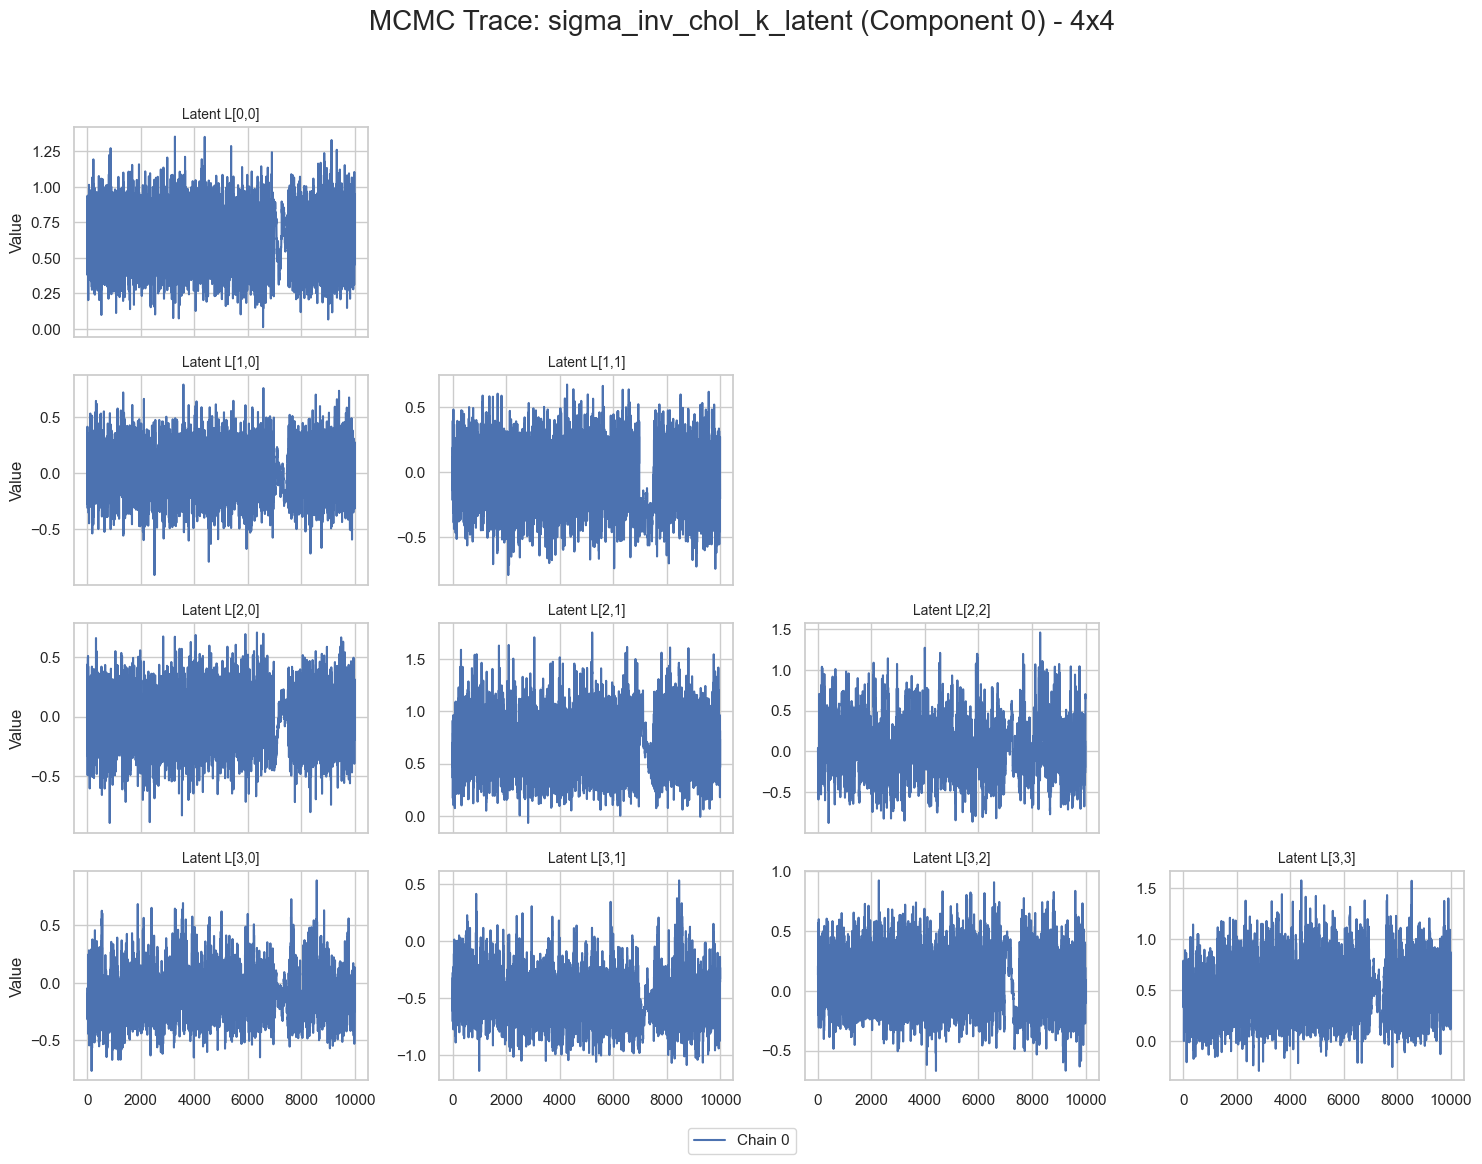

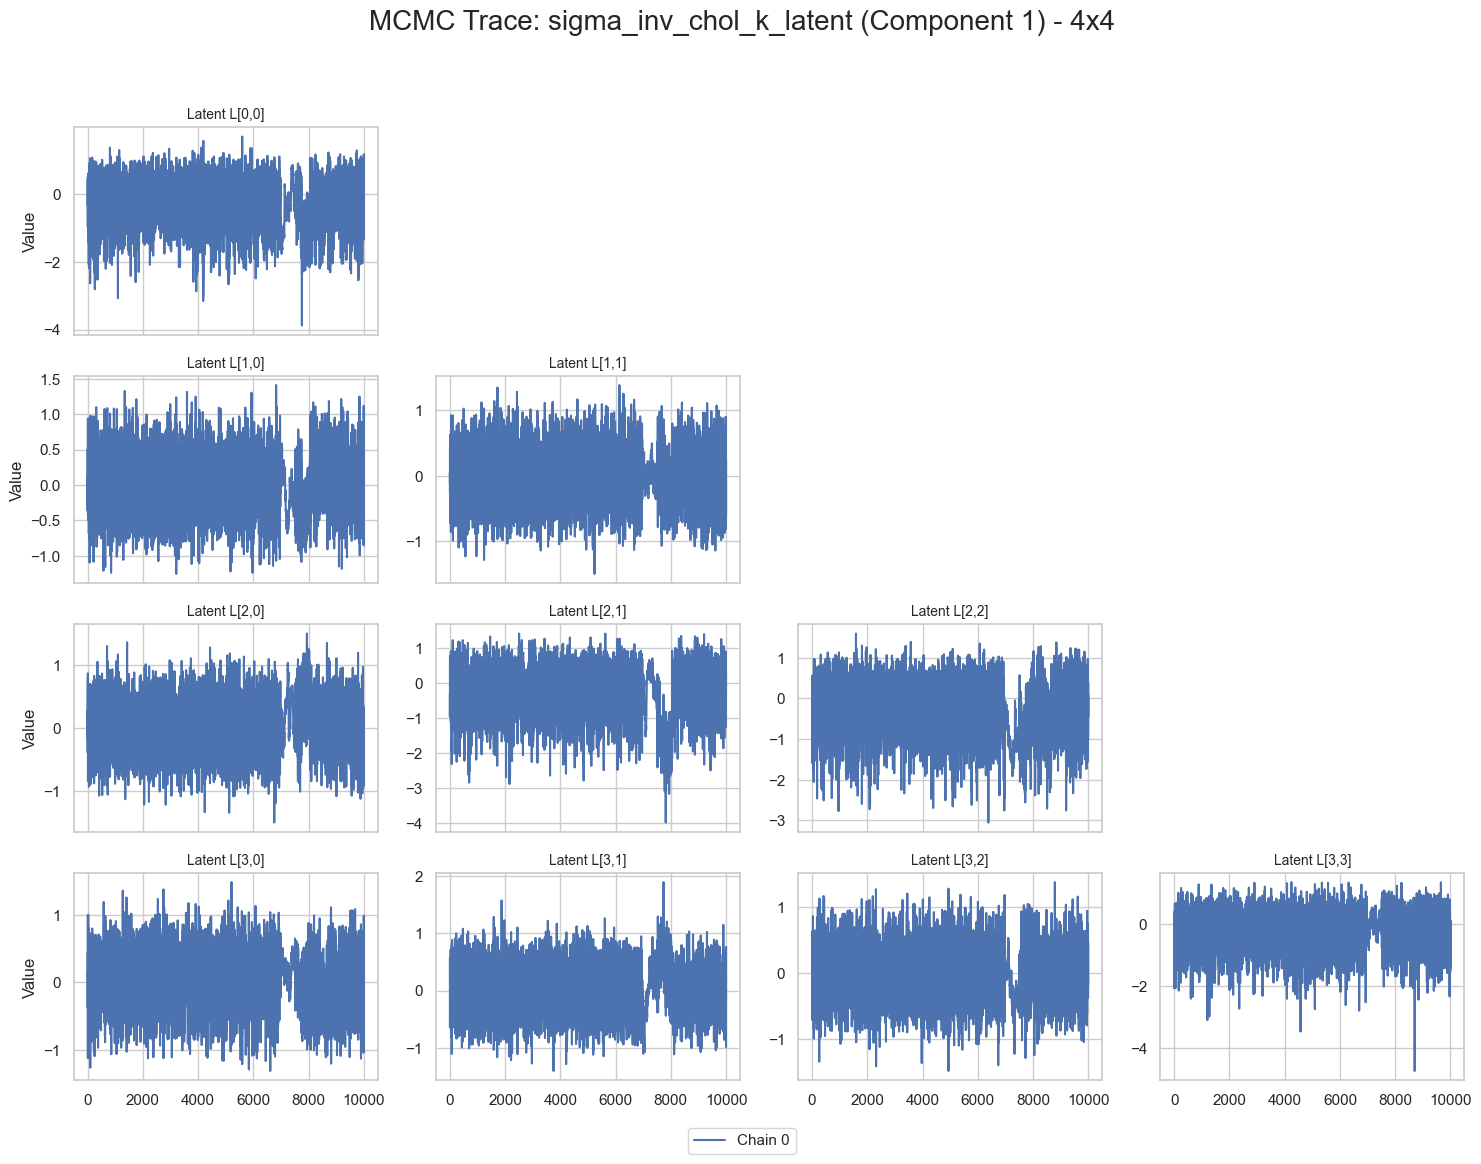

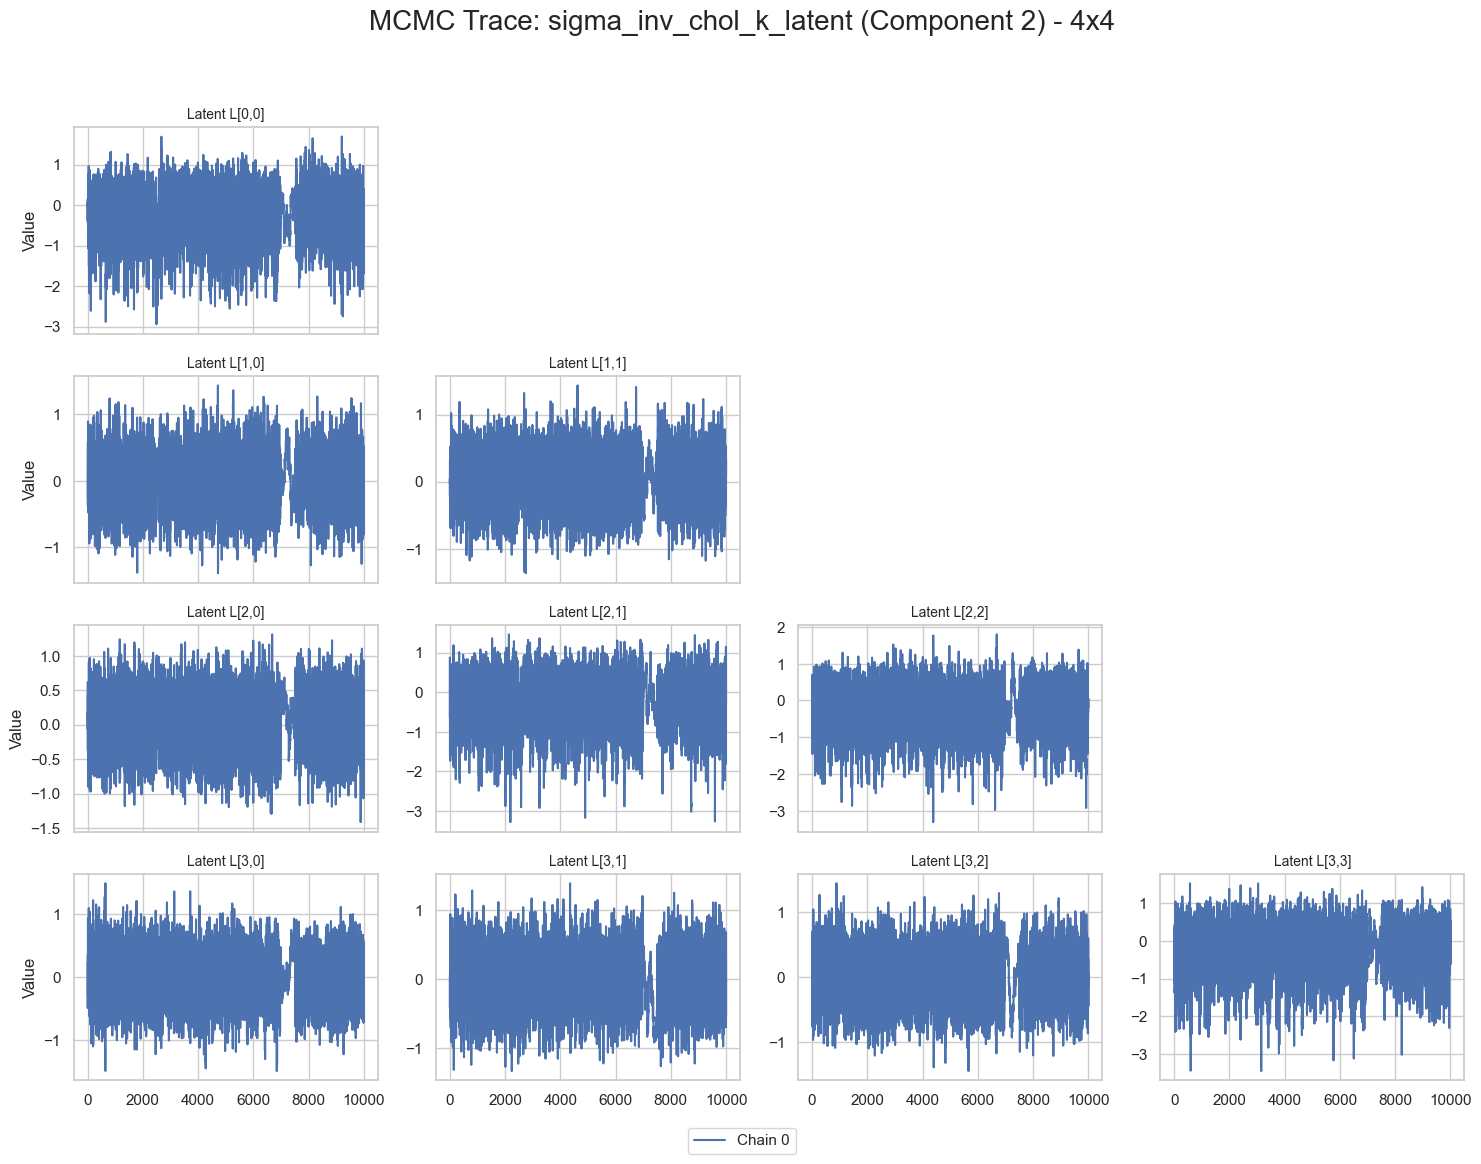

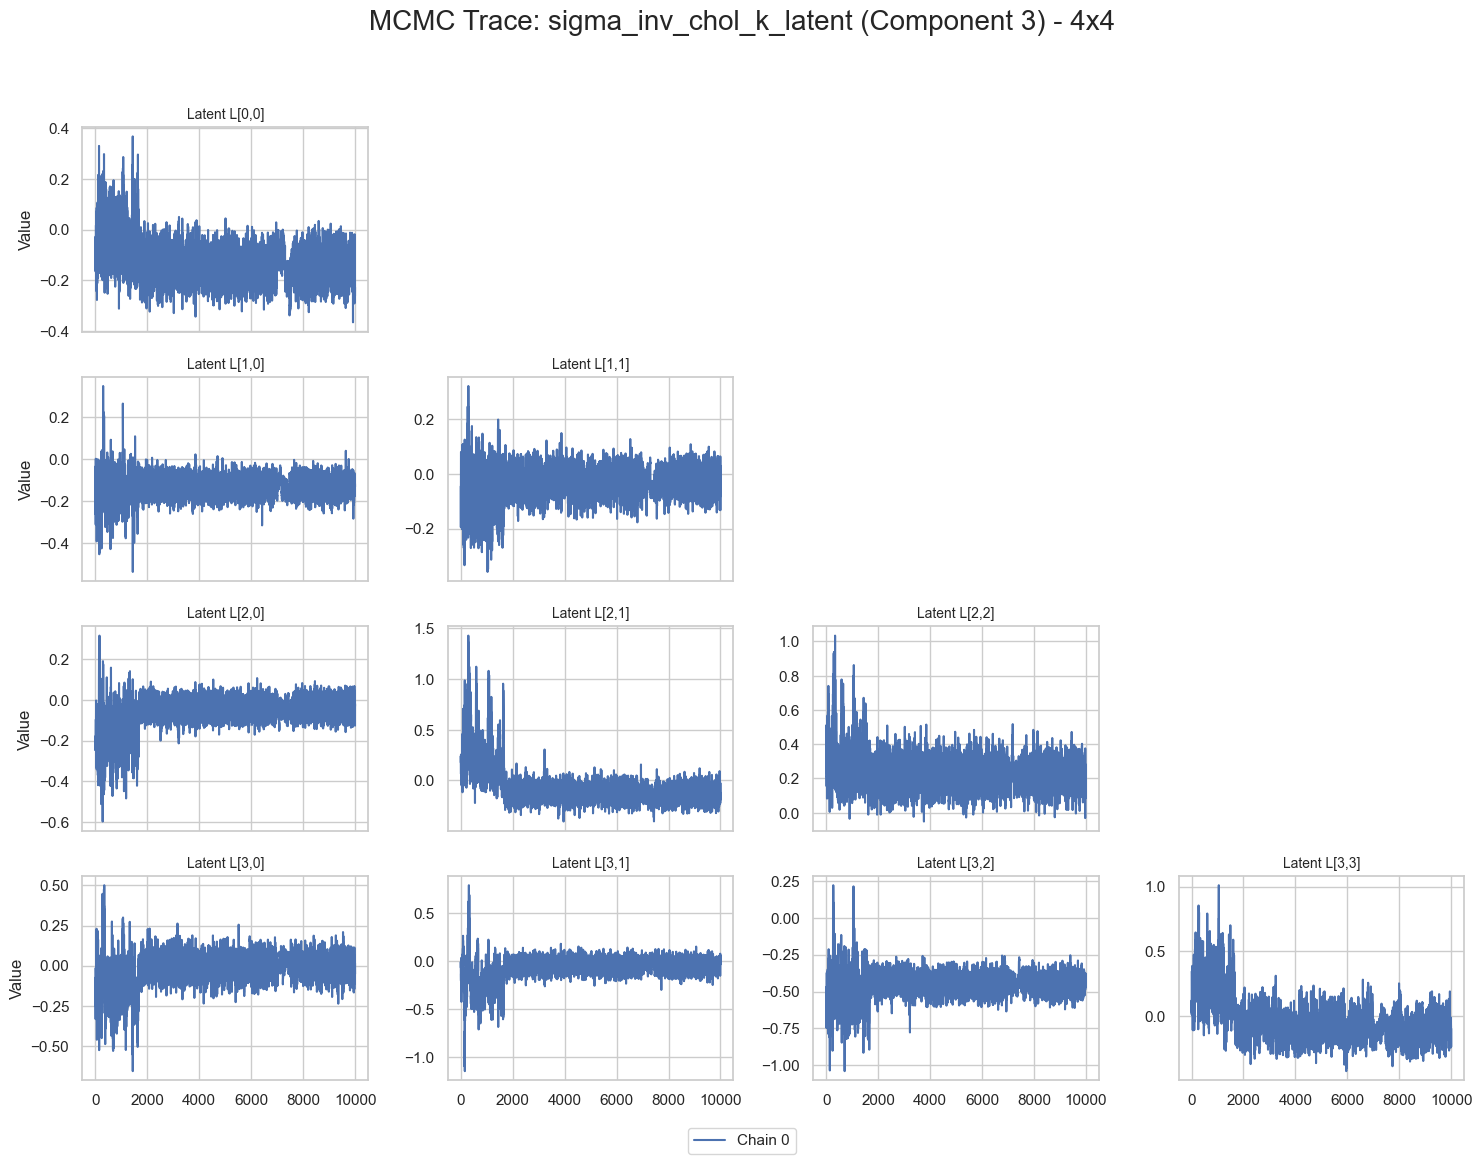

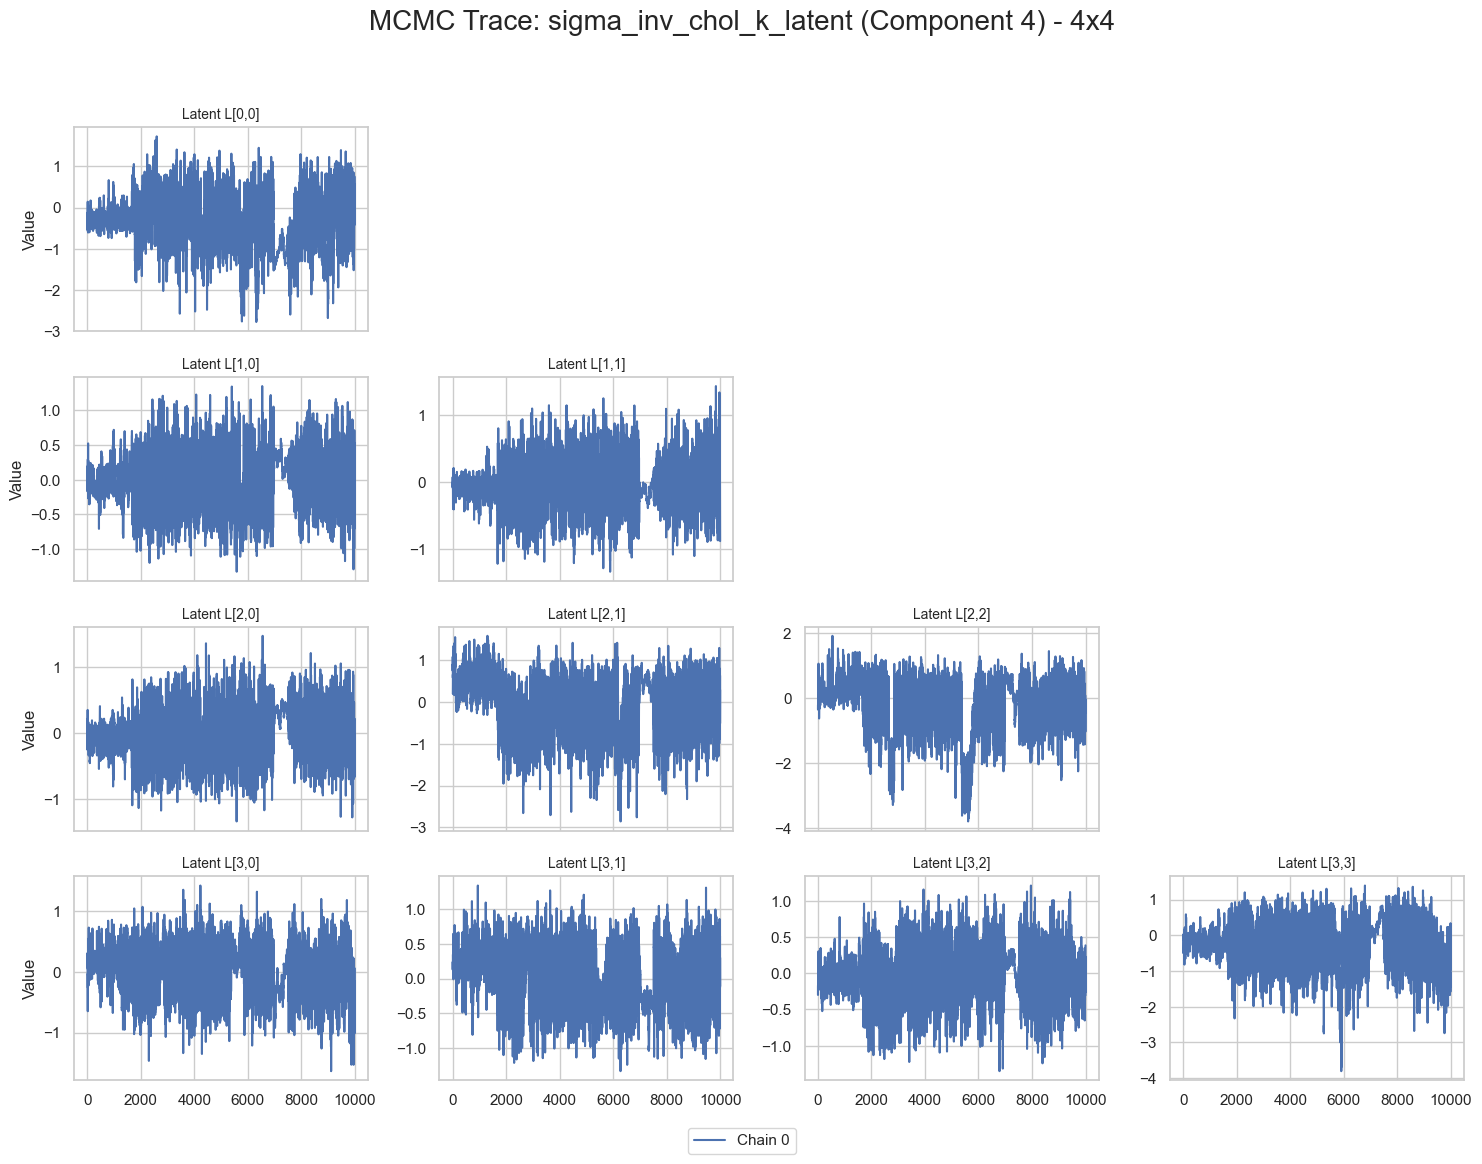


Recovering Covariance Matrices (Sigma_k)...


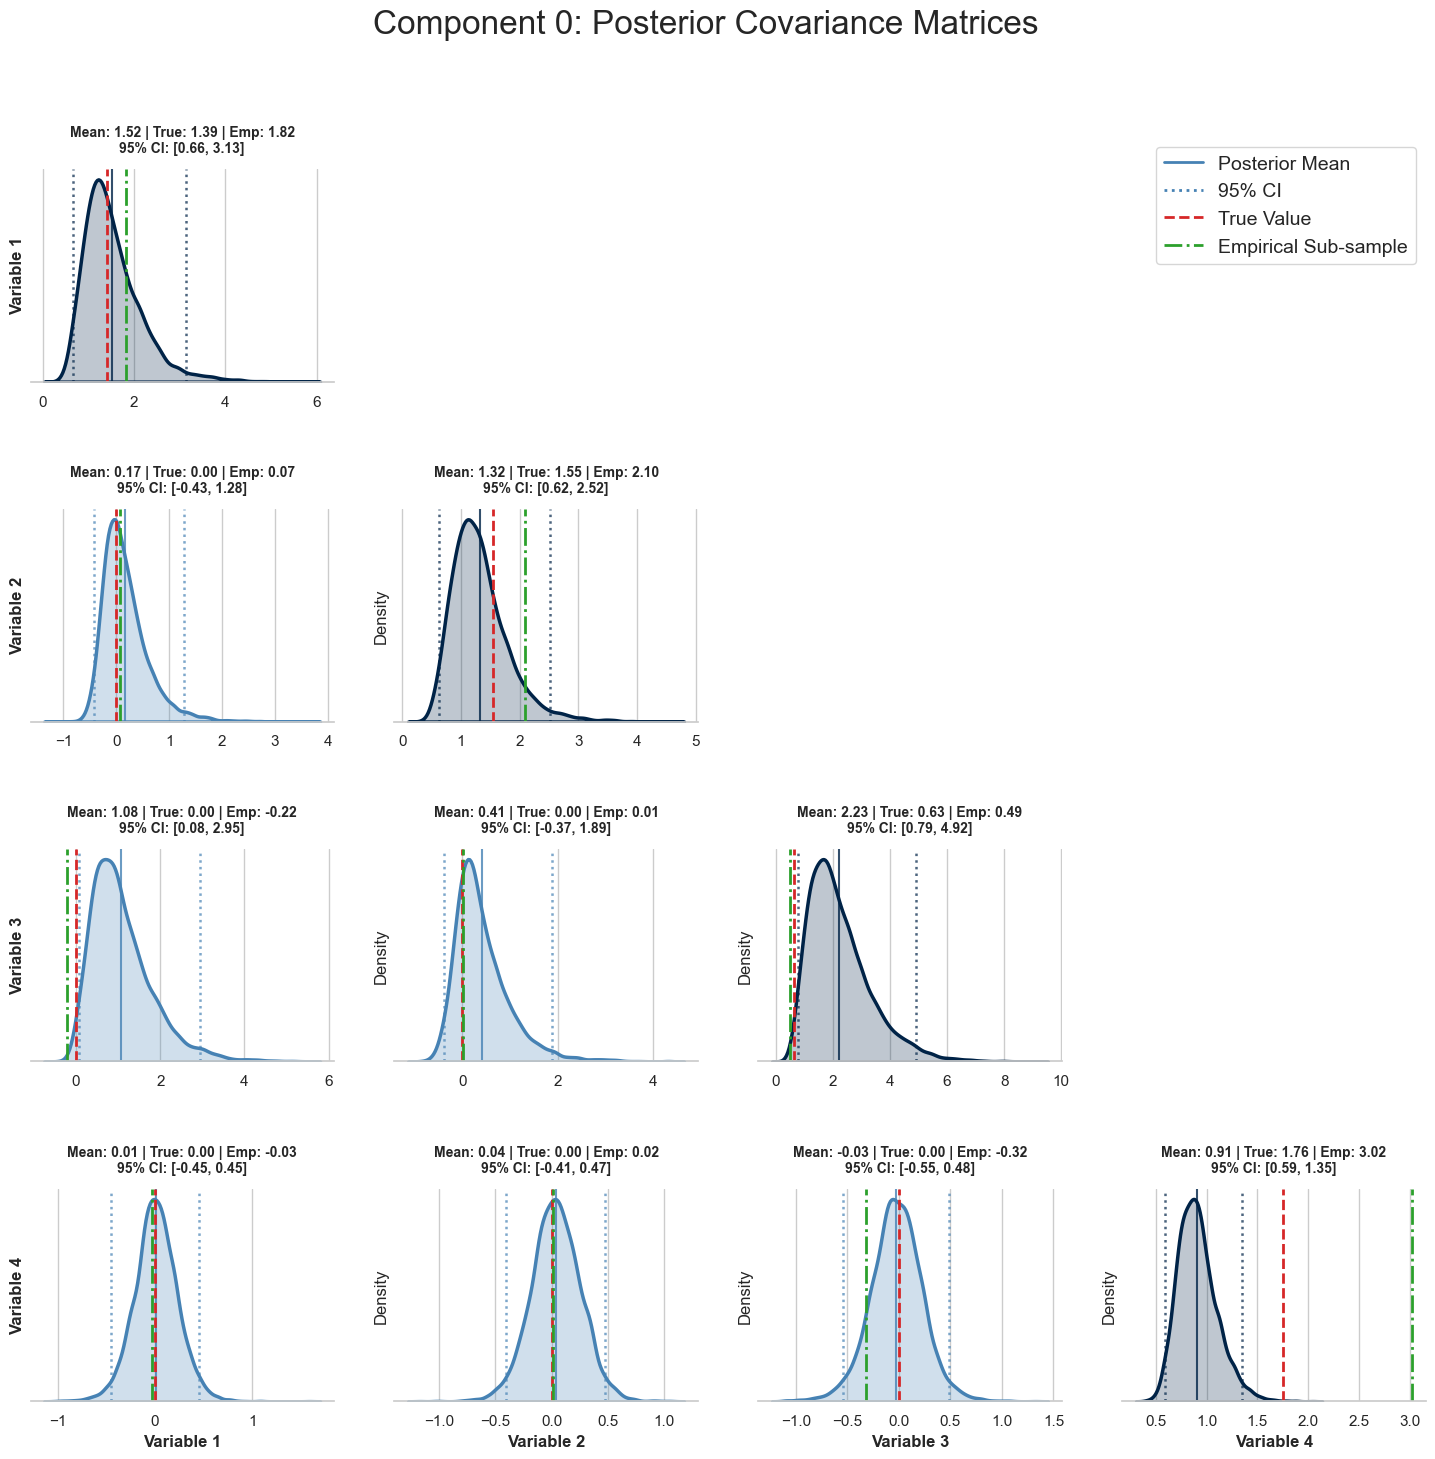

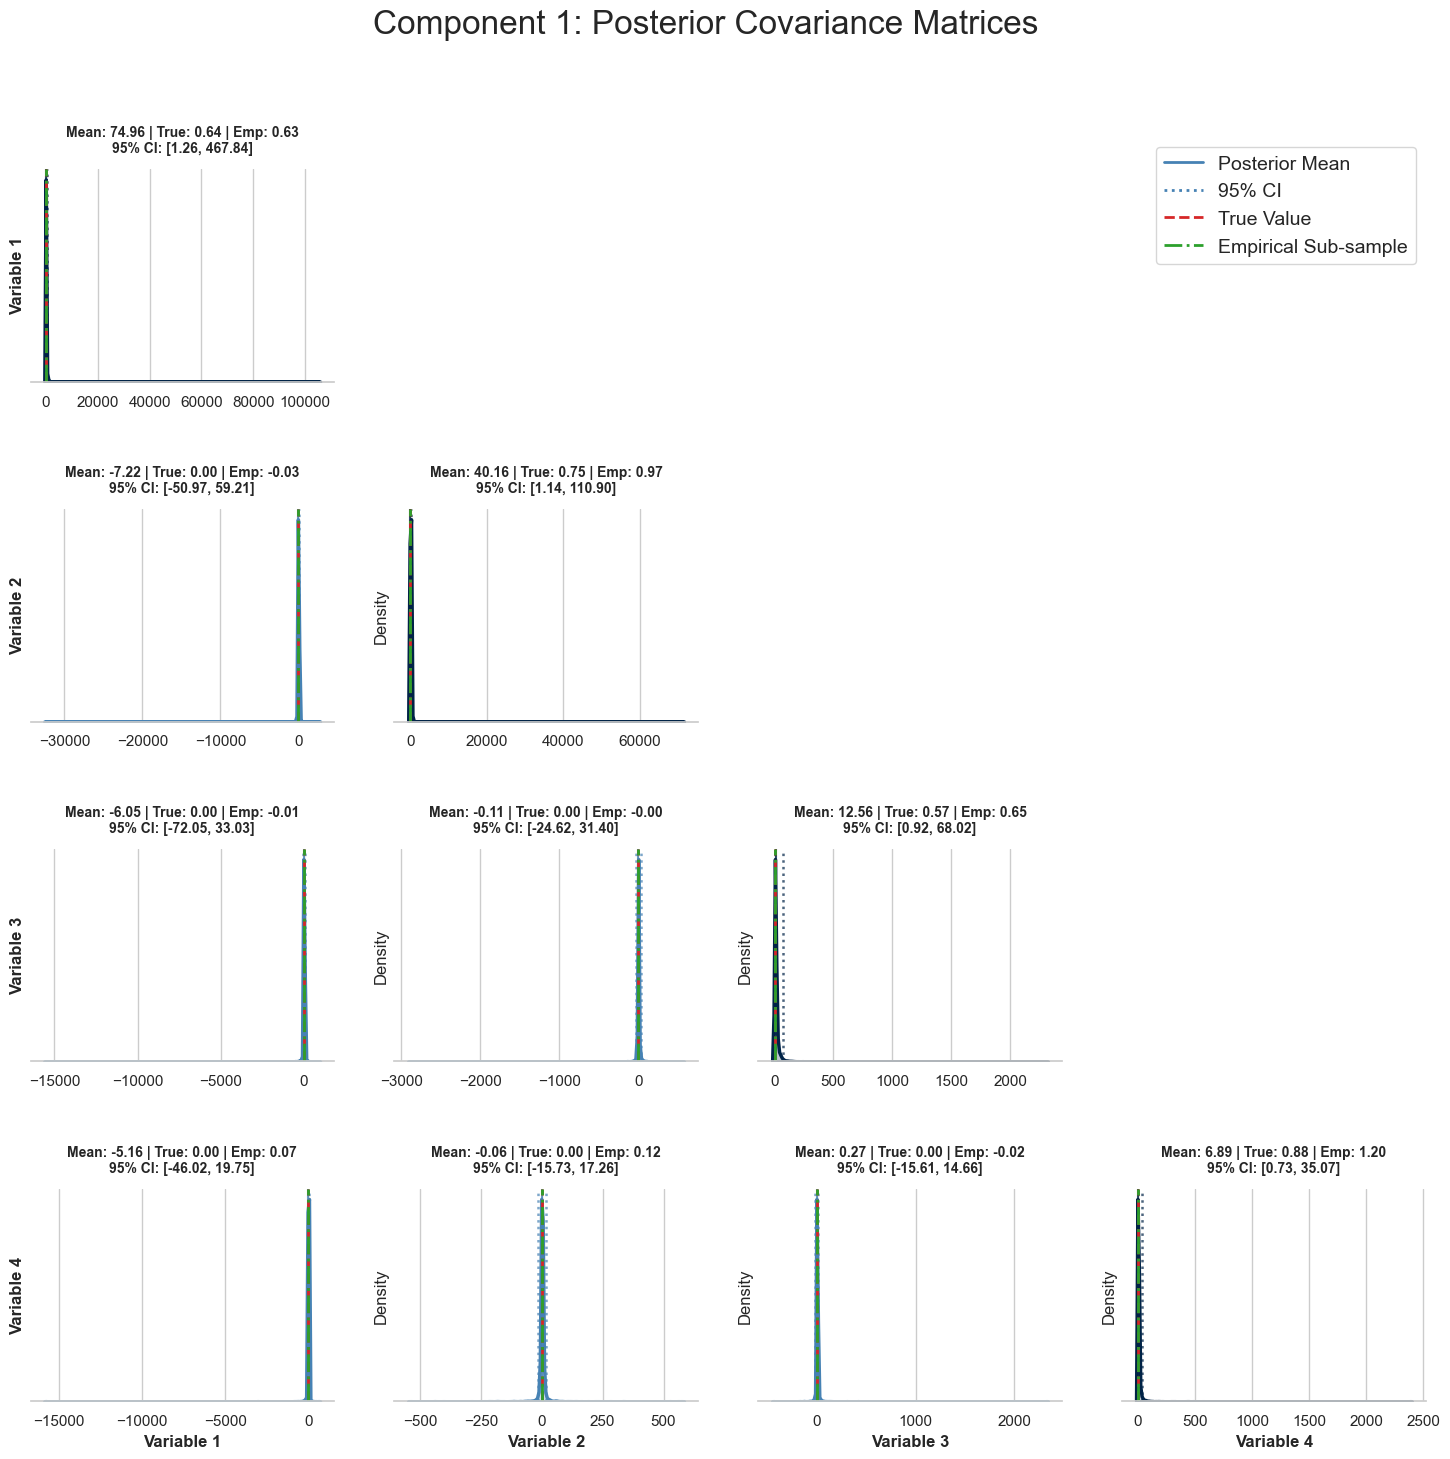

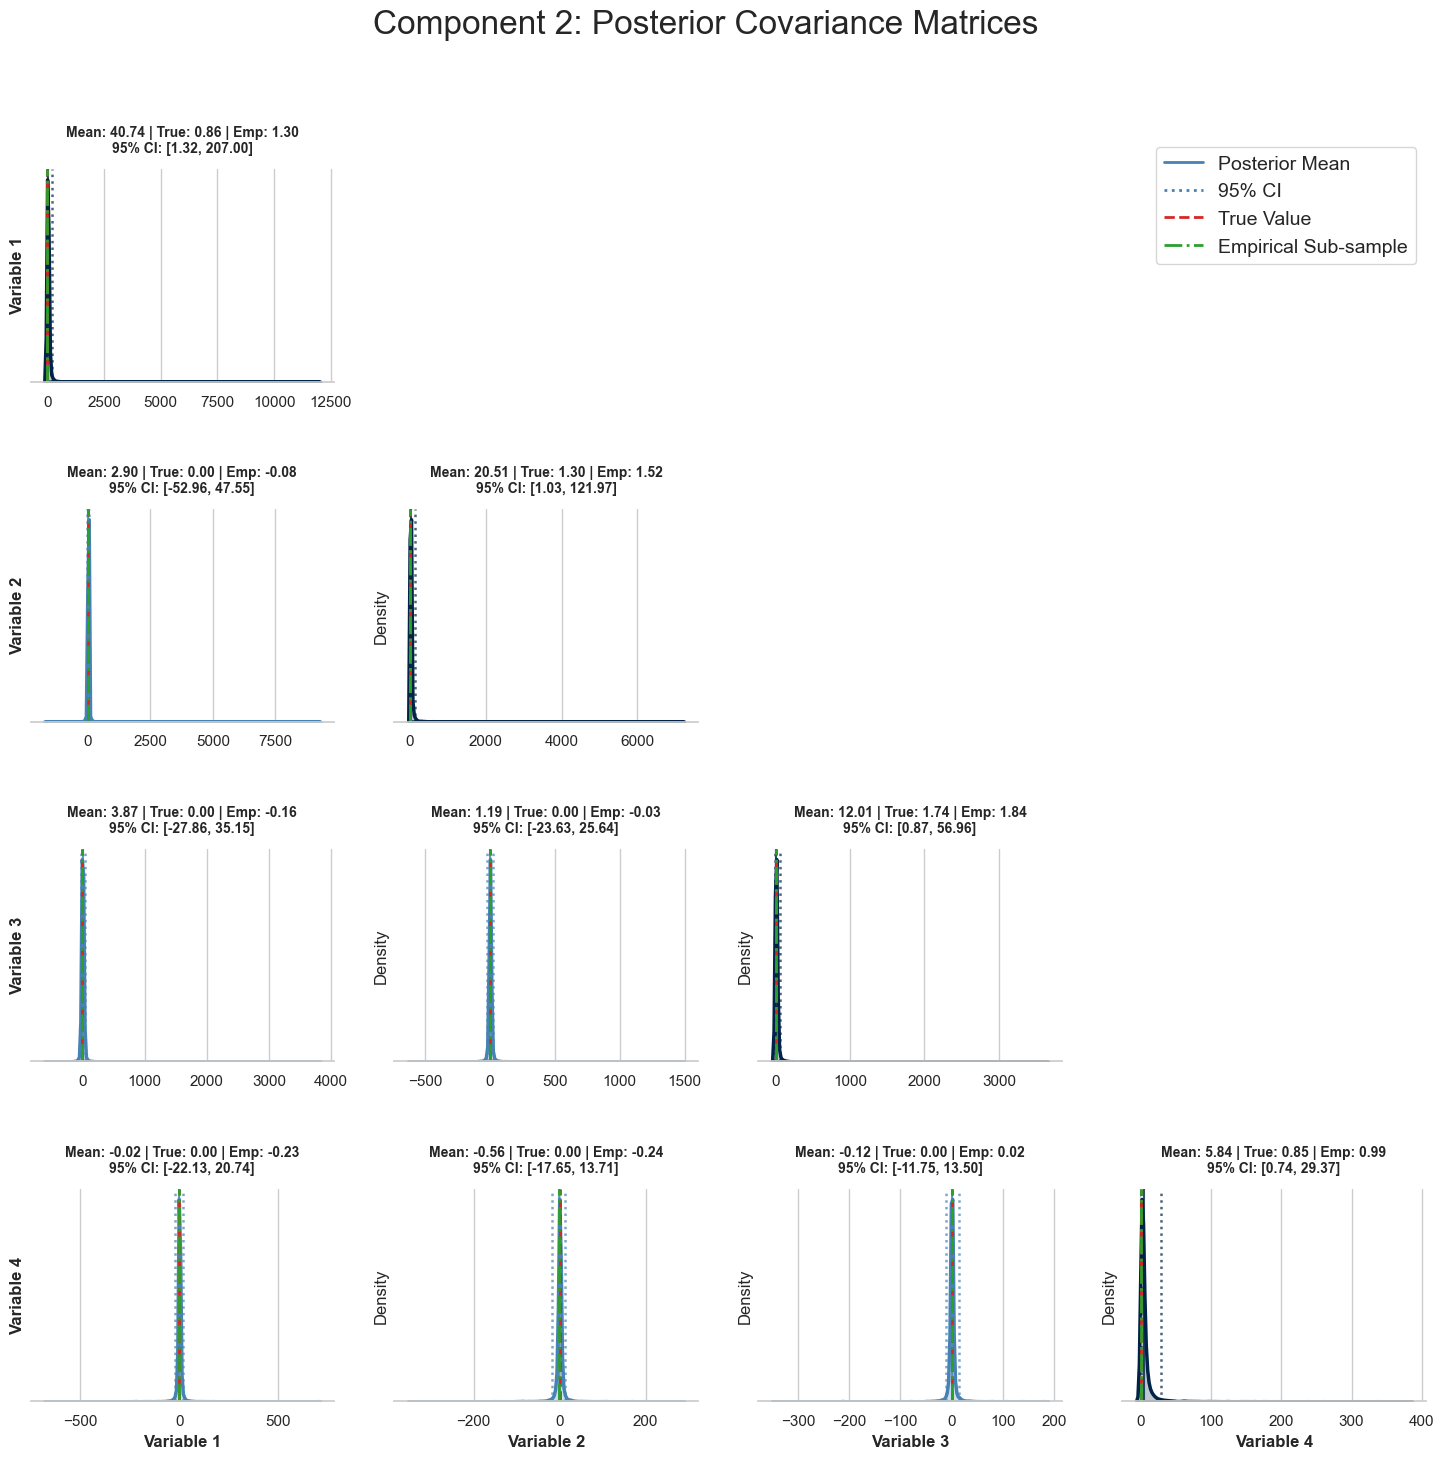

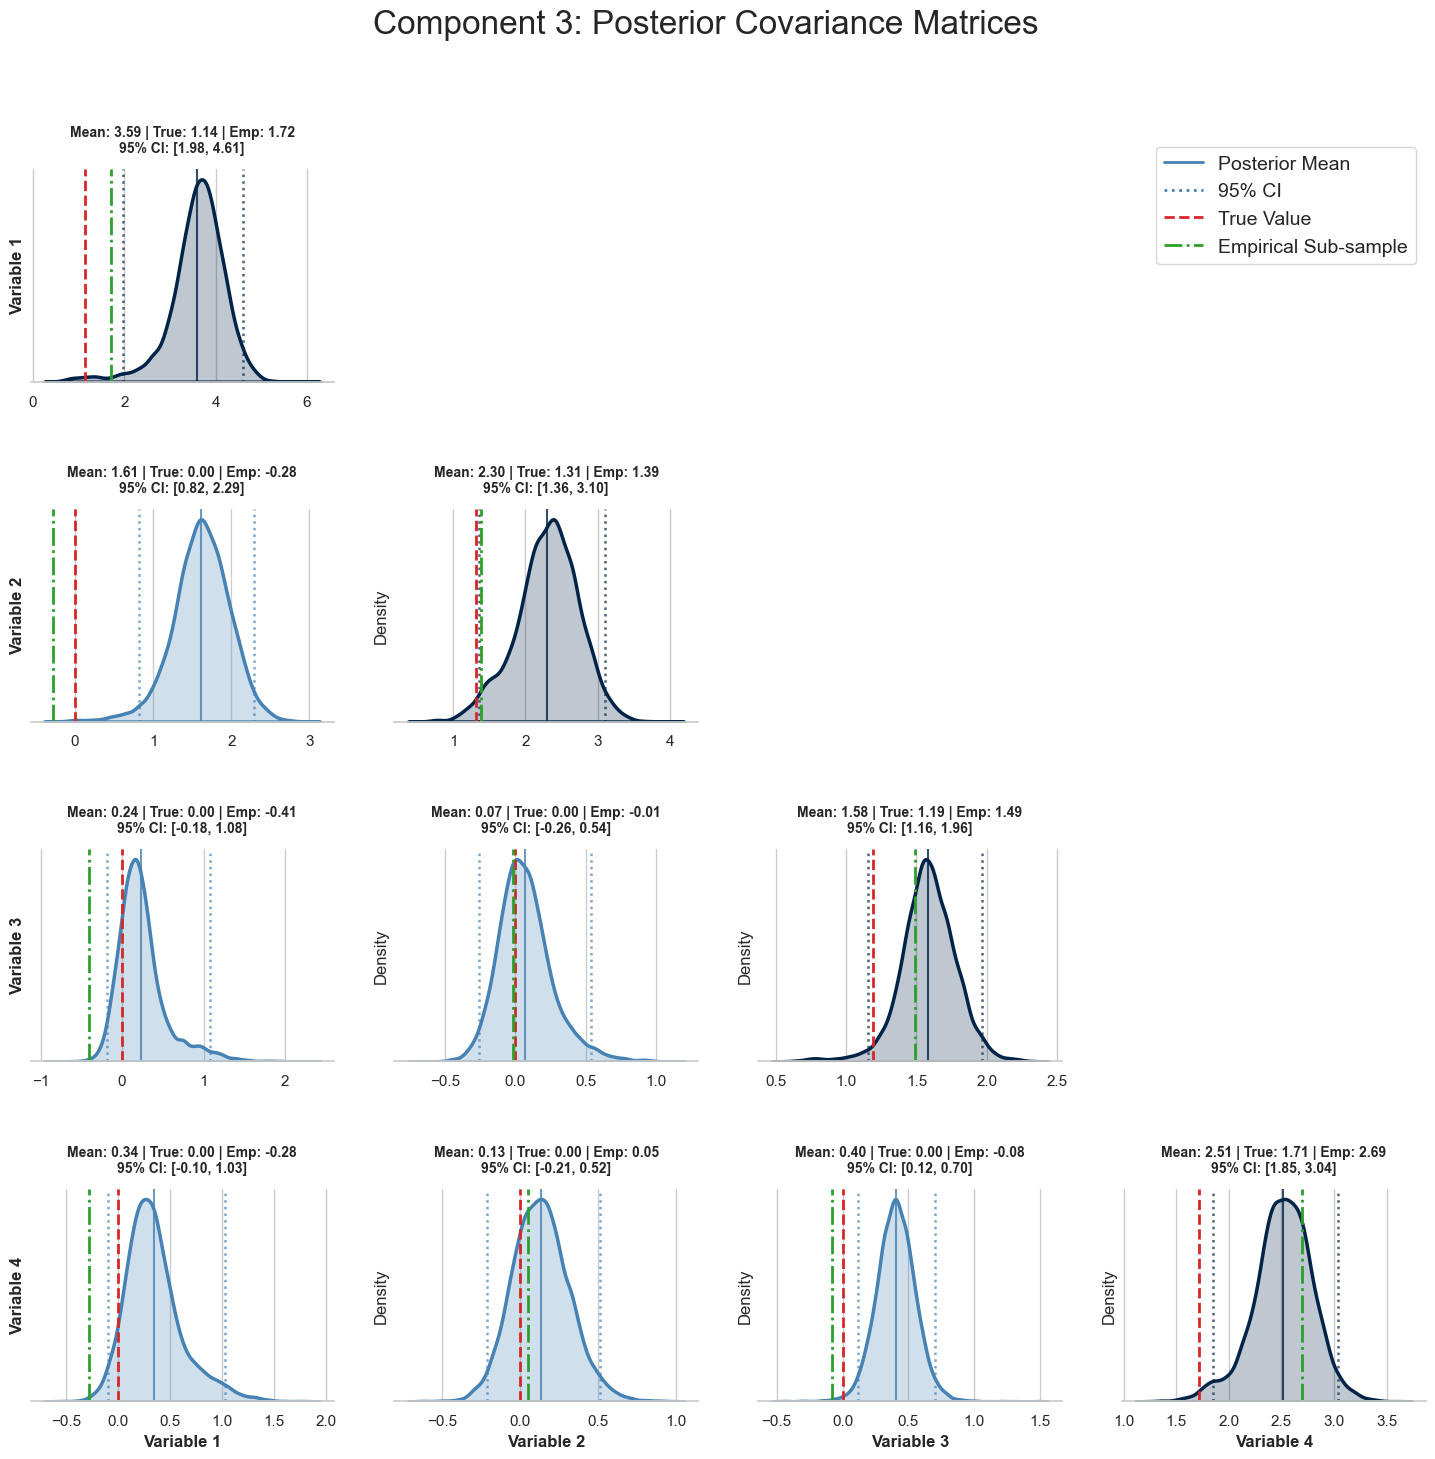

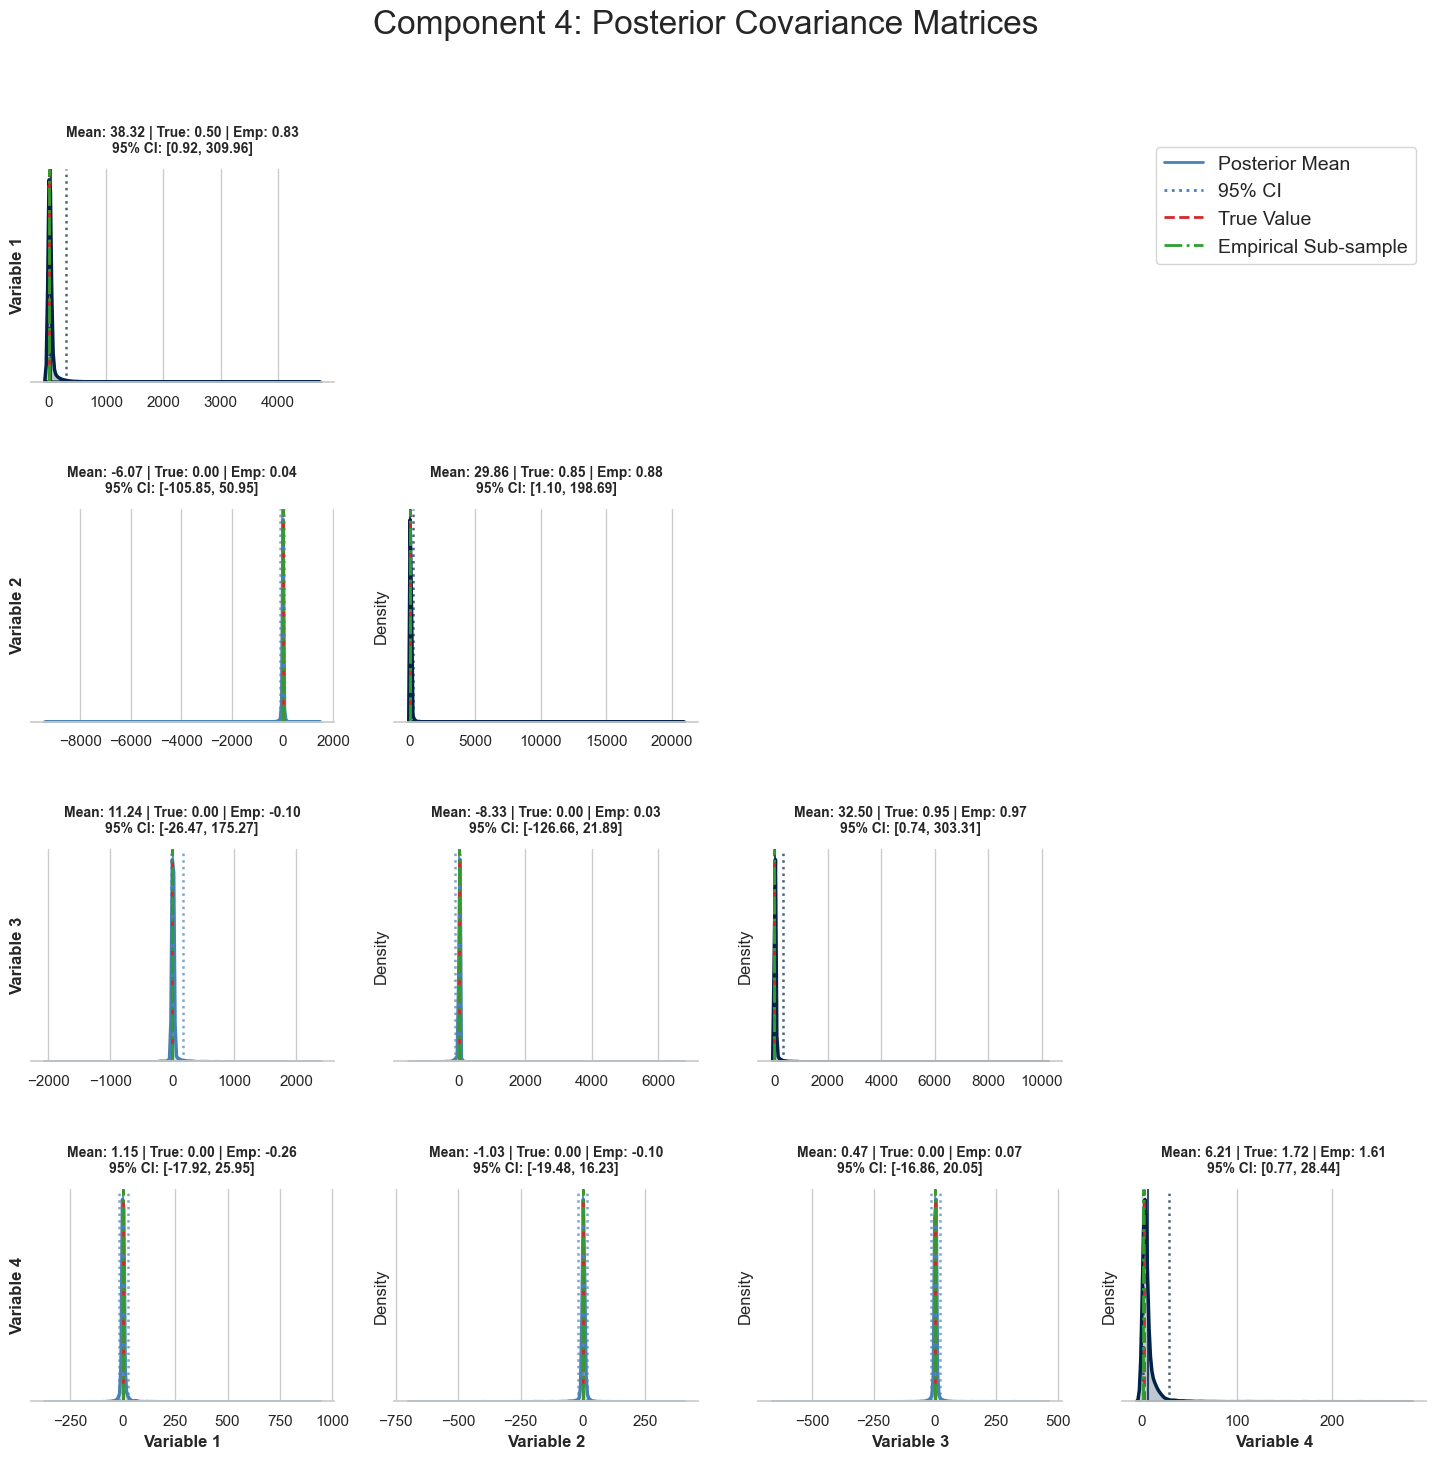


=== Global Parameters (Baseline Means mu_k) Summary Tables ===

--- MCMC Component 0 (Mapped to True Component 1) ---


,True_Value,Posterior_Mean,Posterior_Std,Diff_Abs
Parameter,,,,
Param_0,2.6094,2.6849,0.2527,0.0755
Param_1,2.7177,3.1644,0.2465,0.4467
Param_2,1.3674,1.5291,0.3530,0.1617
Param_3,-1.0784,-0.9874,0.1212,0.0910



--- MCMC Component 1 (Mapped to True Component 0) ---


,True_Value,Posterior_Mean,Posterior_Std,Diff_Abs
Parameter,,,,
Param_0,-0.1593,6.8085,82.248901,6.9679
Param_1,0.7120,-1.7118,43.657700,2.4238
Param_2,-2.0500,0.7994,33.037701,2.8493
Param_3,-0.4538,-0.1905,24.574699,0.2634



--- MCMC Component 2 (Mapped to True Component 2) ---


...


--- MCMC Component 3 (Mapped to True Component 3) ---


,True_Value,Posterior_Mean,Posterior_Std,Diff_Abs
Parameter,,,,
Param_0,-1.4360,-2.5239,0.3278,1.0878
Param_1,-2.0563,-2.1198,0.1717,0.0635
Param_2,-2.3699,-1.8326,0.1207,0.5374
Param_3,-1.4553,-0.4768,0.1232,0.9785



--- MCMC Component 4 (Mapped to True Component 4) ---


,True_Value,Posterior_Mean,Posterior_Std,Diff_Abs
Parameter,,,,
Param_0,-4.1560,-16.682199,52.567299,12.5262
Param_1,-3.0208,10.224900,50.186199,13.2457
Param_2,-1.9606,-17.498501,64.817398,15.5378
Param_3,-0.6859,2.577500,28.279400,3.2634



=== Goose Style Diagnostics for Delta ===


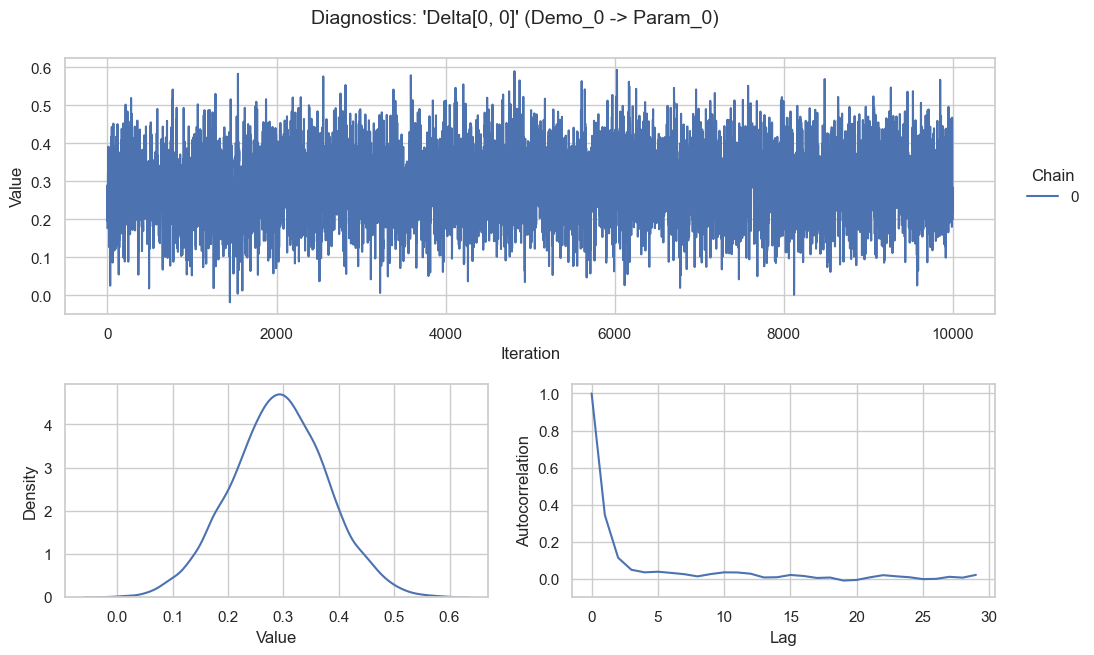

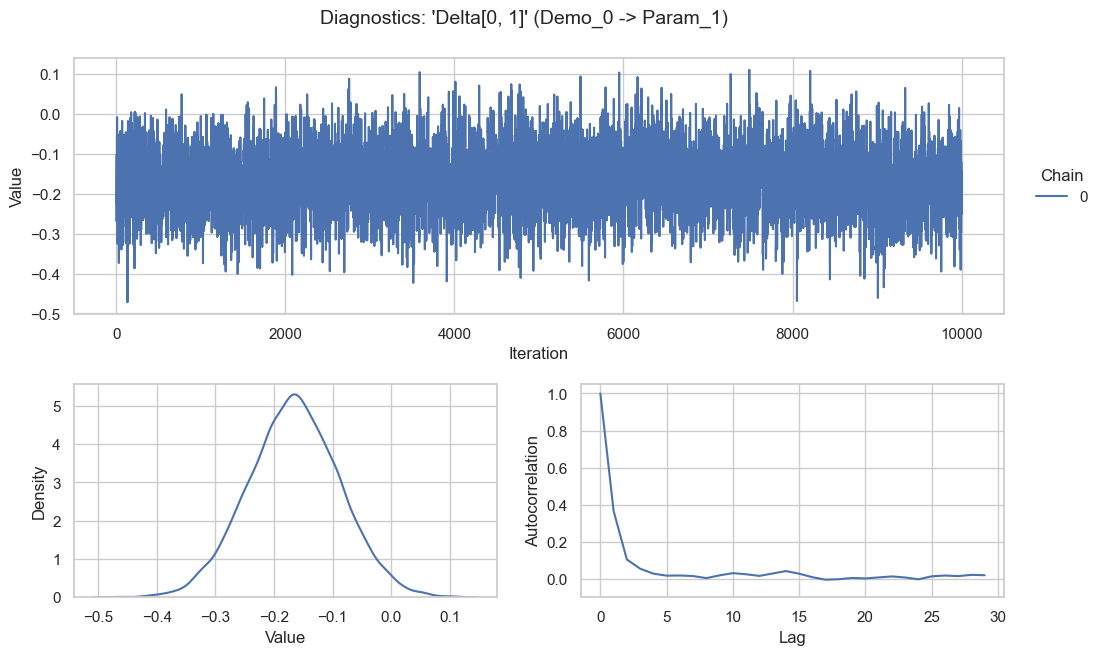

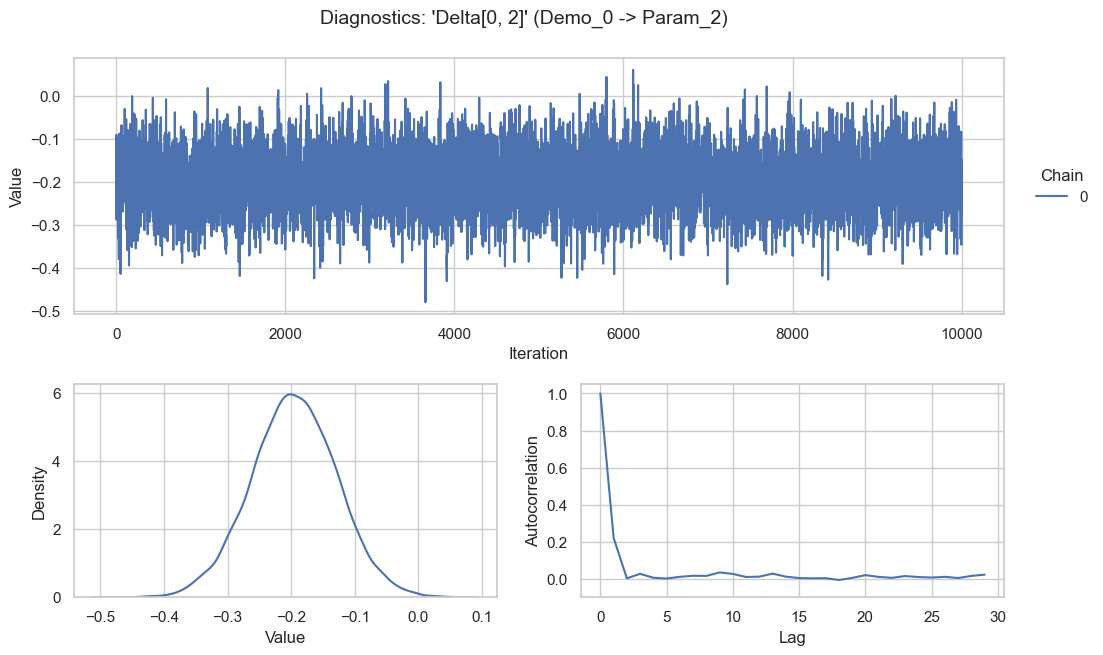

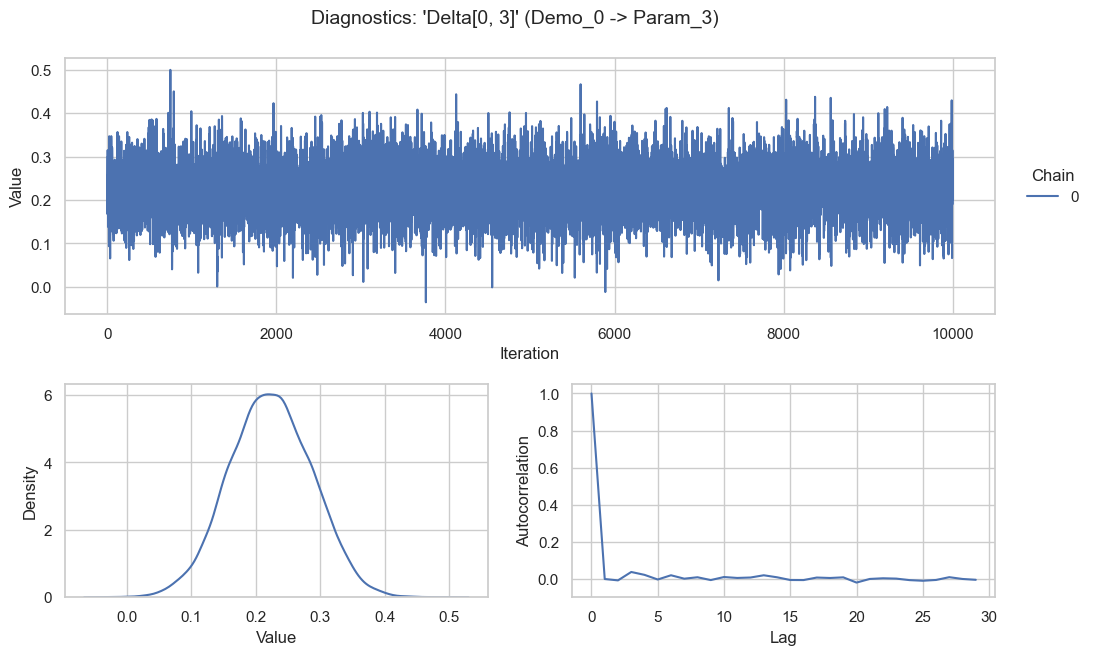

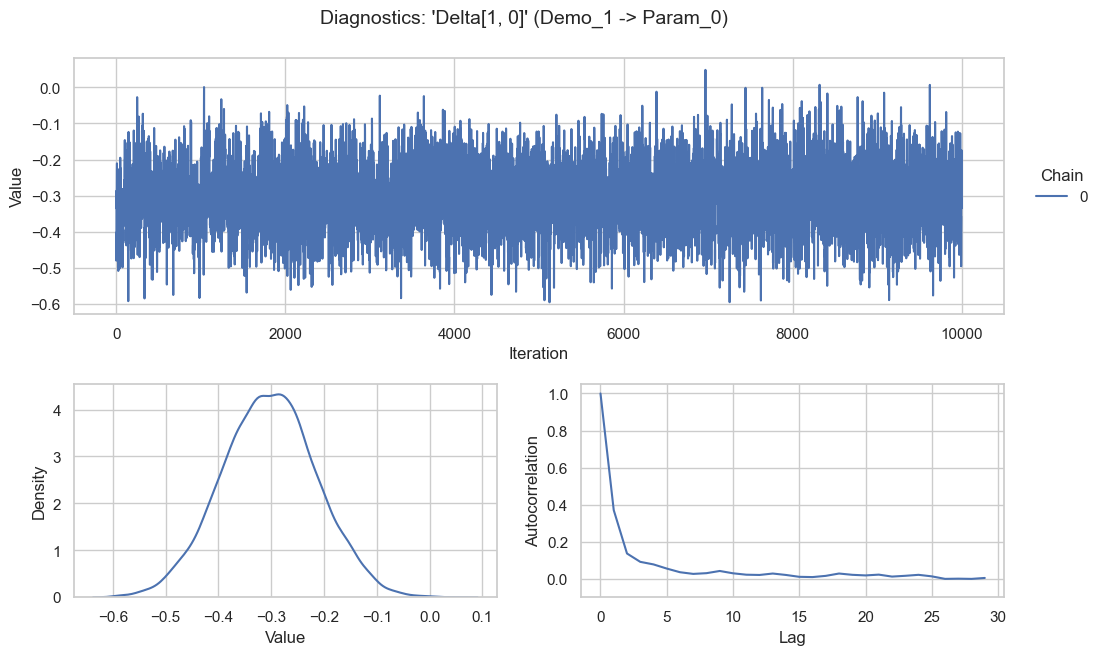

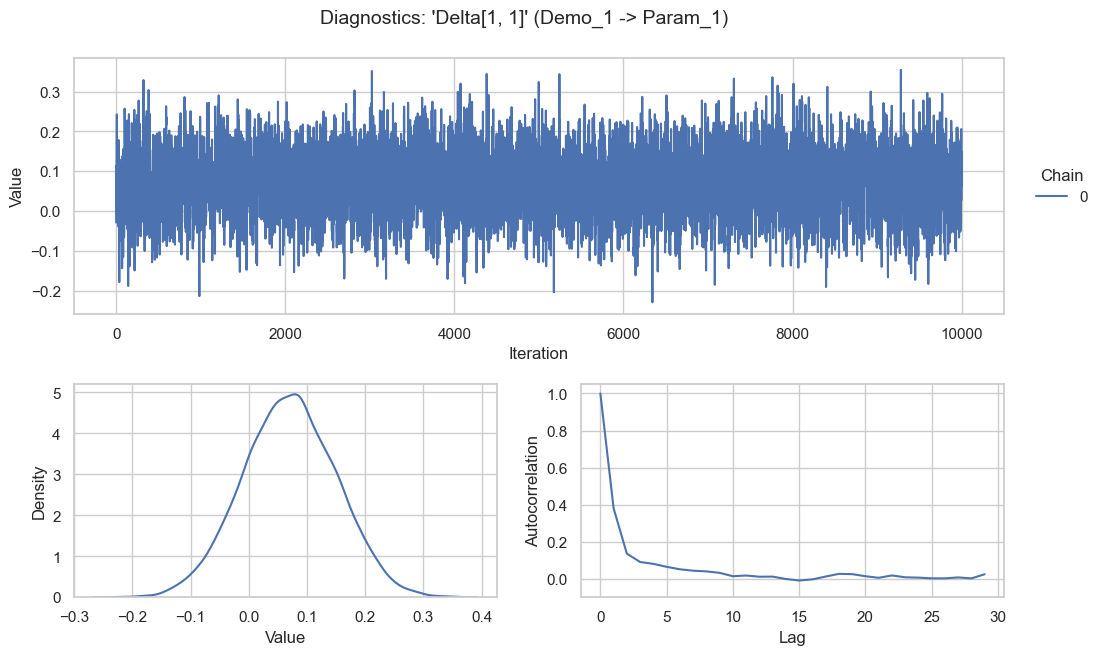

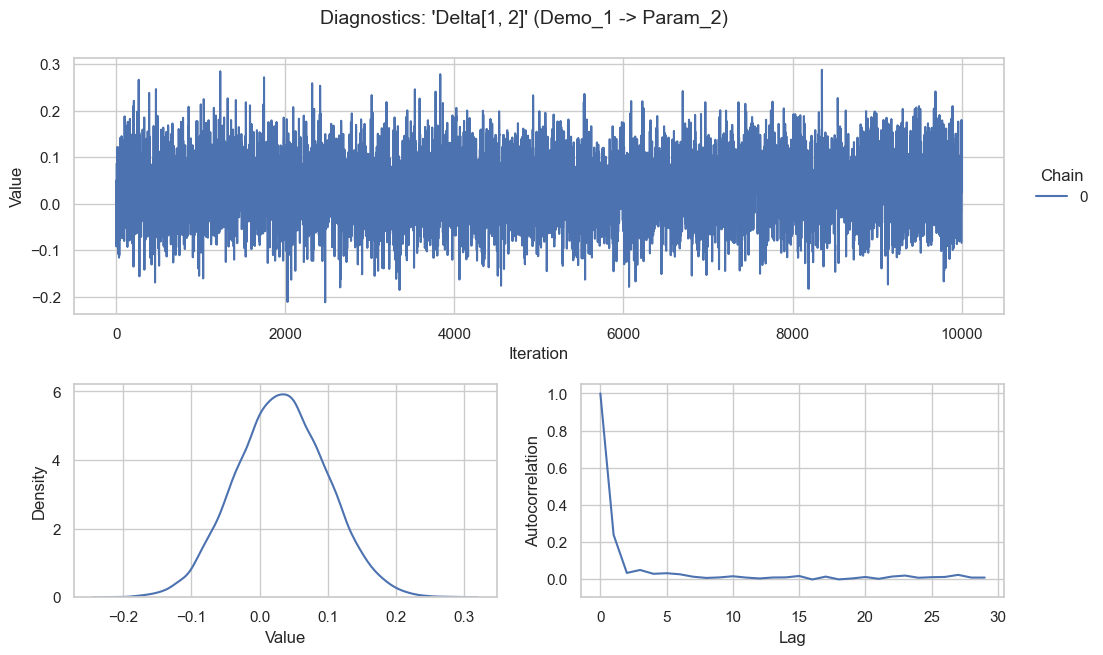

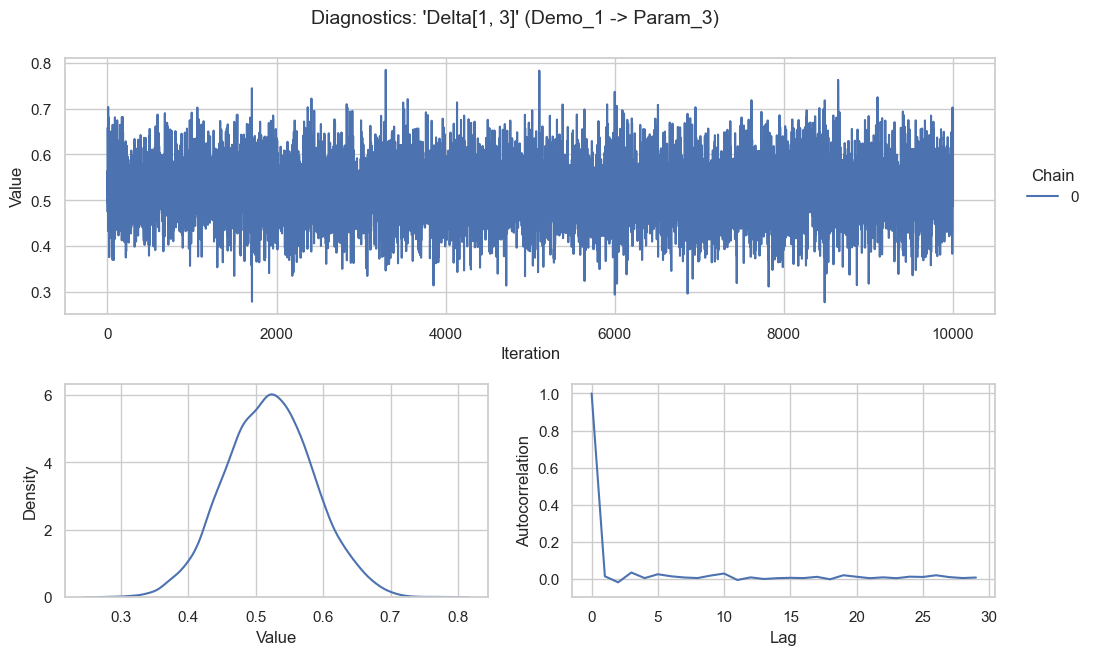


=== Posterior distribution of Delta (mean + std) ===


,Param_0,Param_1,Param_2,Param_3
Demo_0,0.29 (0.09),-0.17 (0.08),-0.20 (0.07),0.22 (0.06)
Demo_1,-0.30 (0.09),0.07 (0.08),0.03 (0.07),0.52 (0.07)



=== Absolute Difference in Delta (|True - Posterior|) ===


,Param_0,Param_1,Param_2,Param_3
Demo_0,0.034,0.128,0.003,0.005
Demo_1,0.049,0.028,0.043,0.003


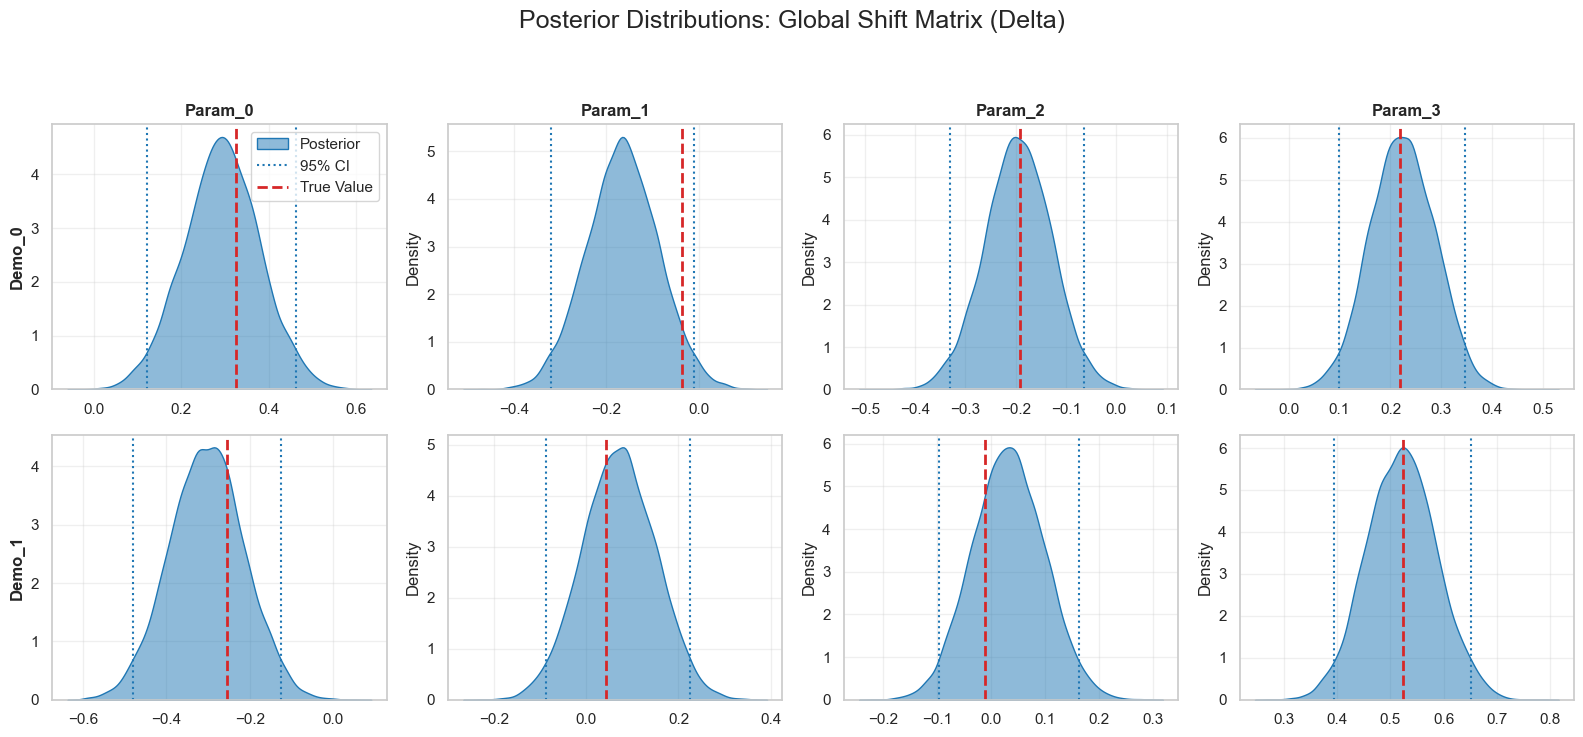

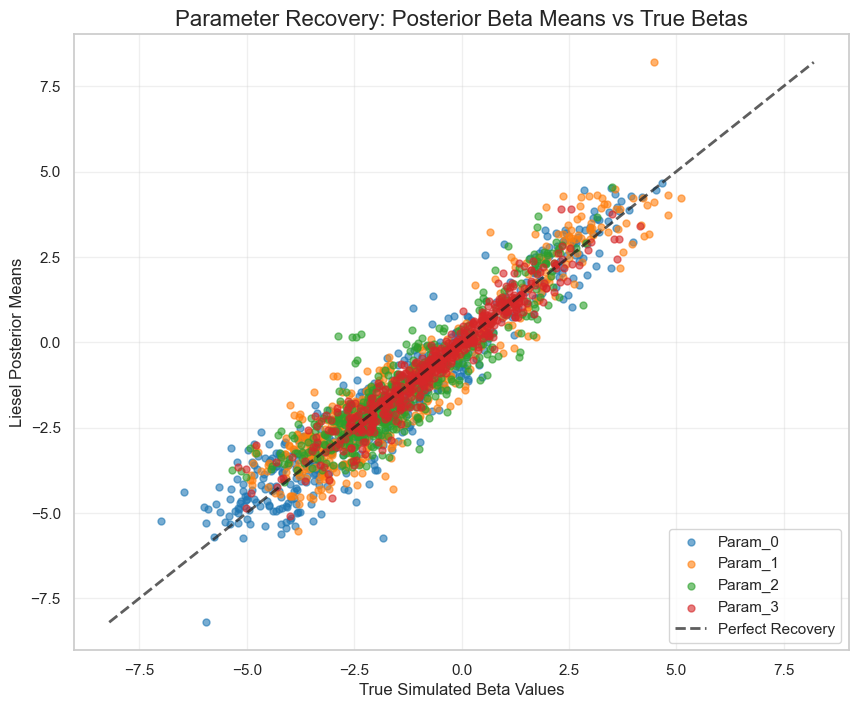


Plotting Household-Level Distributions for Unit 0...


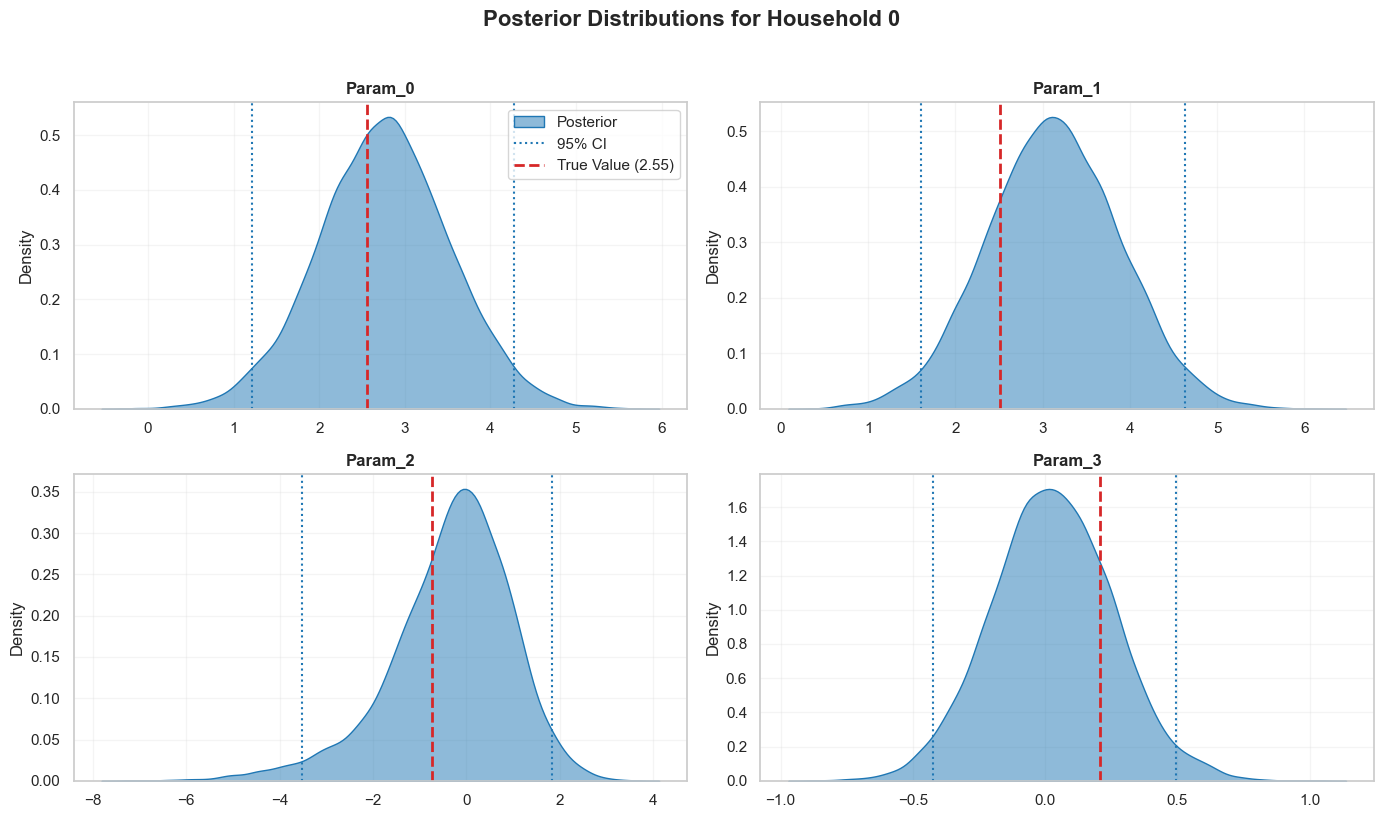


Plotting Household-Level Distributions for Unit 499...


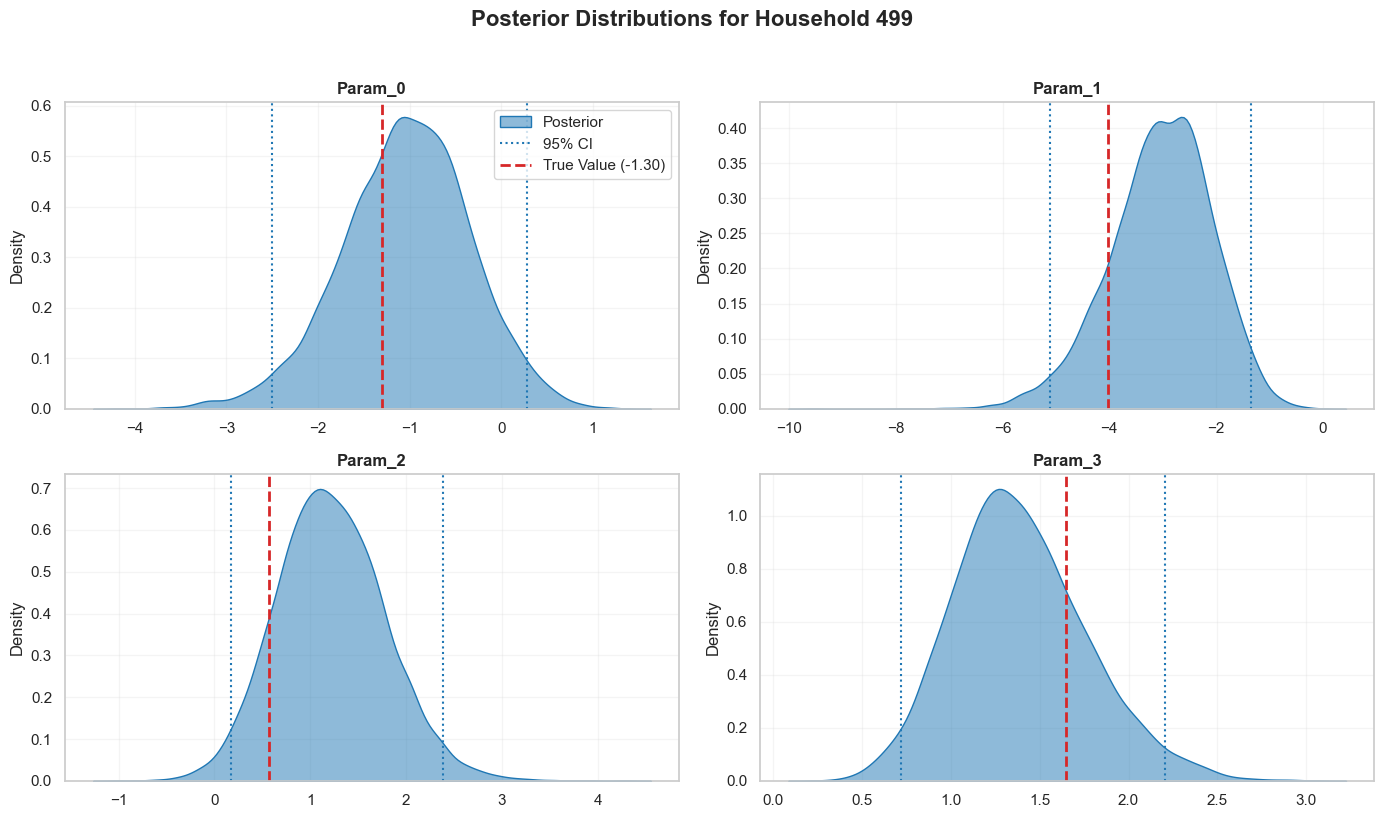


=== pvec: Goose-Style Chain Diagnostics ===


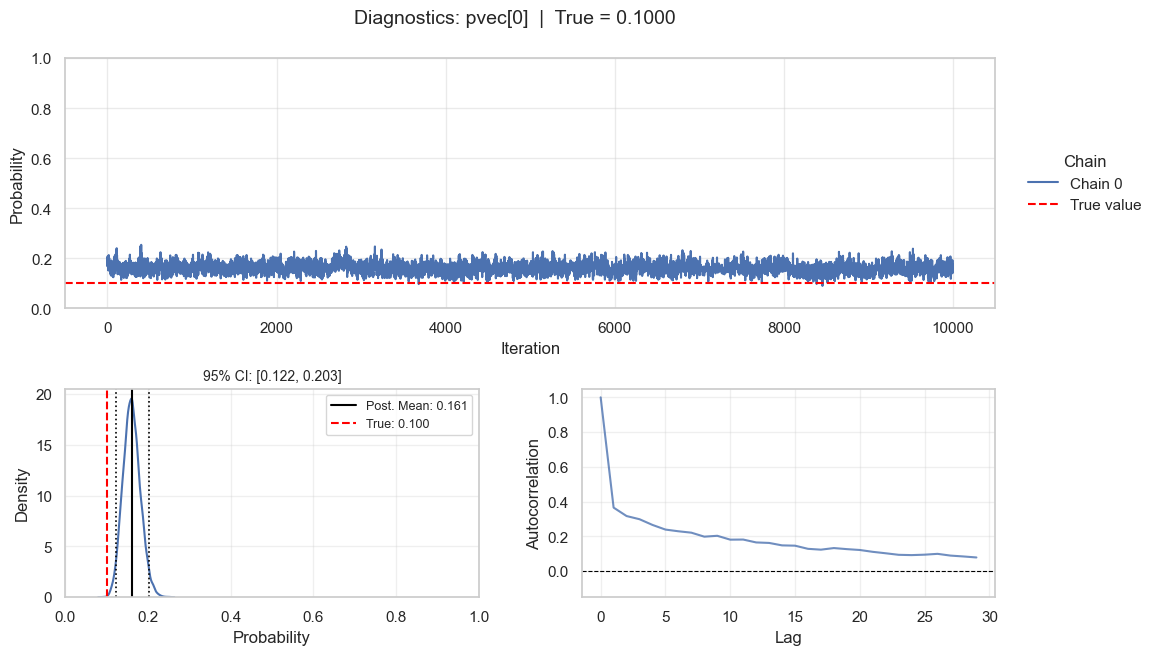

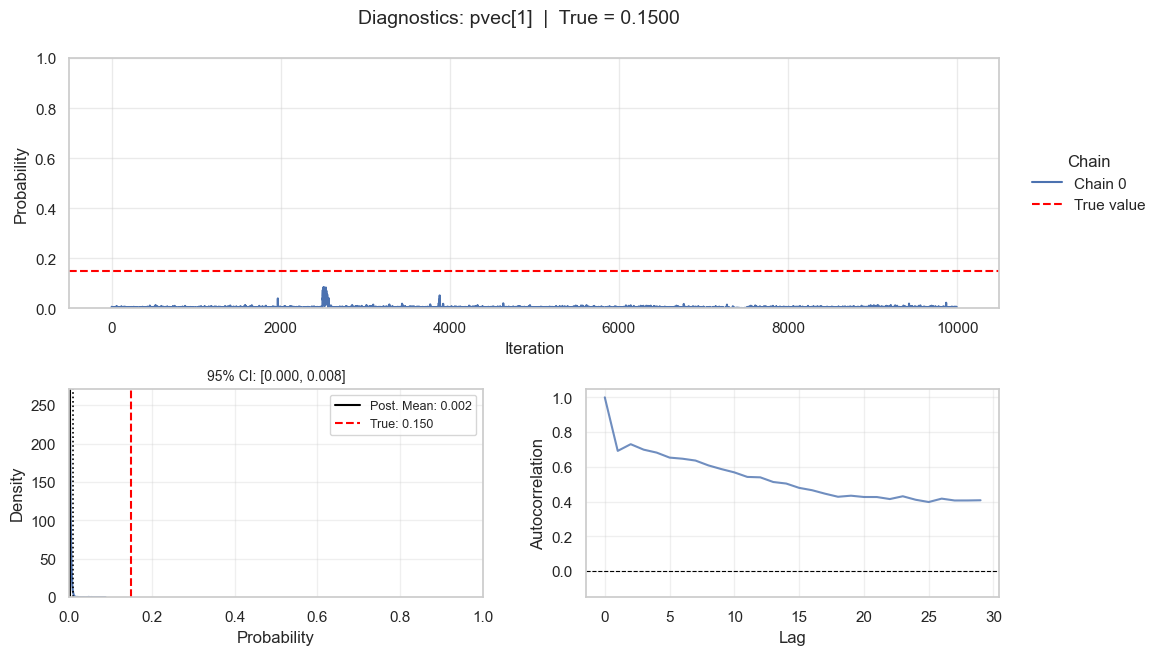

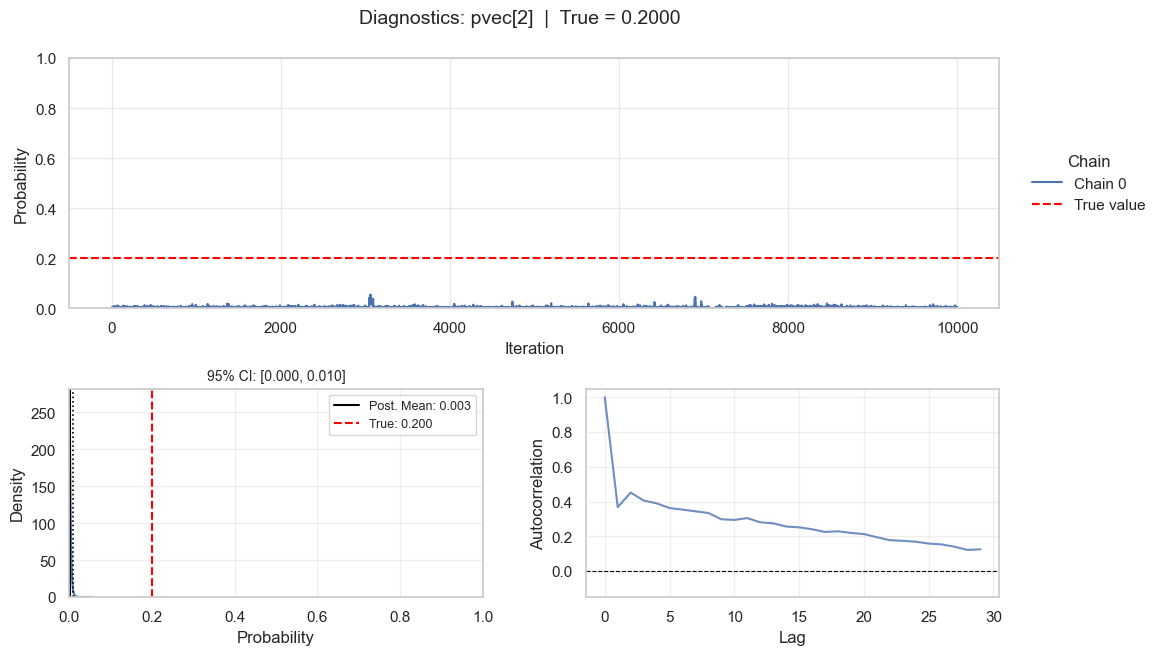

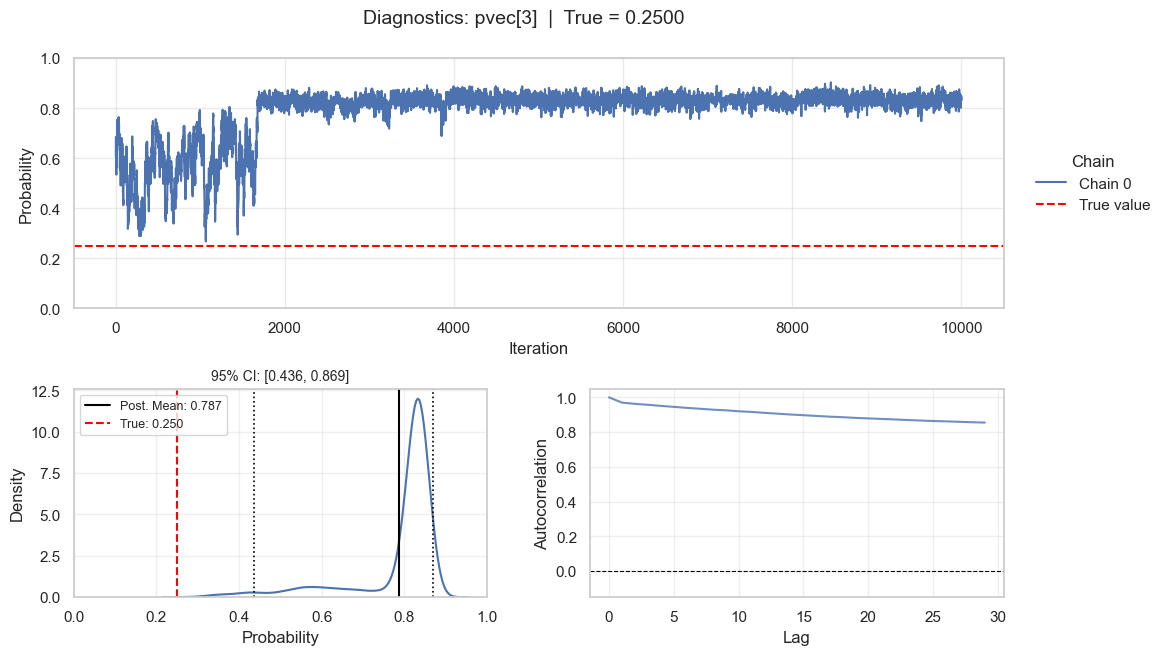

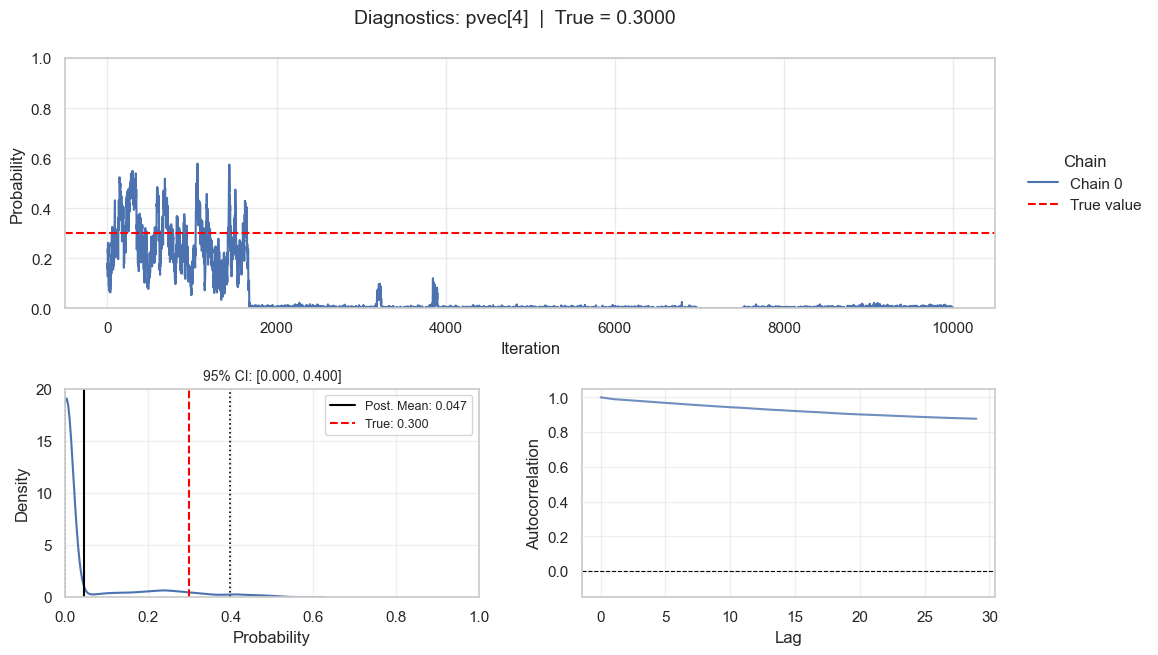


=== pvec: Posterior Summary ===


,Posterior_Mean,Posterior_Std,CI_2.5%,CI_97.5%,True_pvec,True_in_CI
Component,,,,,,
0,0.16098073,0.020789139,0.1224,0.2035,0.10,False
1,0.002467589,0.0046187984,0.0001,0.0085,0.15,False
2,0.0026004906,0.0031748791,0.0001,0.0099,0.20,False
3,0.7872937,0.10923352,0.4361,0.8694,0.25,False
4,0.04665753,0.10701054,0.0000,0.3998,0.30,True


In [5]:
# ── Cell 5 : MCMC Diagnostics & Analysis ───────────────────────────────────────

# Extract parameters
P = choice_data["n_params"]
D = choice_data.get("n_demos", 0)
K = choice_data["K"]
n_units = choice_data["n_units"]

param_names = [f"Param_{i}" for i in range(P)]
demo_names = [f"Demo_{i}" for i in range(D)]

# Extract Ground Truth
t_sigma = choice_data.get("TRUE_SIGMA_K")
t_delta = choice_data.get("TRUE_DELTA")
t_beta  = choice_data.get("TRUE_BETA")
t_pvec  = choice_data.get("TRUE_PVEC")
t_mu    = choice_data.get("TRUE_MU_K")
t_inds  = choice_data.get("TRUE_INDICATORS")

samples_to_analyze = posterior_samples  # or posterior_samples_sorted

# ── 1. Latent Cholesky Traces ──
for k in range(K):
    plot_cholesky_traces(samples_to_analyze, n_params=P, k_idx=k)


# ── 2. Covariance Matrices ──
print("\nRecovering Covariance Matrices (Sigma_k)...")
latent_samples = samples_to_analyze["sigma_inv_chol_k_latent"]
sigma_samples  = recover_covariance_matrices(latent_samples)

for k in range(K):
    emp_sigma = None
    if t_inds is not None and t_beta is not None:
        comp_betas = t_beta[t_inds == k]
        if len(comp_betas) > 1: emp_sigma = np.cov(comp_betas, rowvar=False)

    plot_final_covariance_complete(
        samples=sigma_samples[:, :, k, :, :],
        true_matrix=t_sigma[k] if t_sigma is not None else None,
        empirical_matrix=emp_sigma,
        component_idx=k
    )

# ── 3. Global Parameters (mu_k & Delta) ──
summarize_mu_k(samples_to_analyze["mu_k"], K, P, param_names, true_mu=t_mu)

if D > 0 and "Delta" in samples_to_analyze:
    raw_delta_samples = samples_to_analyze["Delta"]
    delta_flat = raw_delta_samples.reshape(-1, D, P)
    
    print("\n=== Goose Style Diagnostics for Delta ===")
    for i in range(D):
        for j in range(P):
            plot_goose_style_diagnostics(
                raw_delta_samples, demo_idx=i, param_idx=j,
                demo_name=demo_names[i], param_name=param_names[j]
            )
            
    generate_delta_summaries(delta_flat, param_names, demo_names, true_delta=t_delta)
    plot_delta_distributions(delta_flat, param_names, demo_names, true_delta=t_delta)


# ── 4. Household Heterogeneity (Betas) ──
plot_beta_scatter(samples_to_analyze["beta_i"], t_beta, param_names)

liesel_beta_full = samples_to_analyze["beta_i"].reshape(-1, n_units, P)

print("\nPlotting Household-Level Distributions for Unit 0...")
plot_beta_distributions(
    samples=liesel_beta_full[:, 0, :], 
    p_names=param_names, 
    title_prefix="Posterior Distributions for Household 0",
    true_vals=t_beta[0, :] if t_beta is not None else None
)

print(f"\nPlotting Household-Level Distributions for Unit {n_units - 1}...")
plot_beta_distributions(
    samples=liesel_beta_full[:, -1, :], 
    p_names=param_names, 
    title_prefix=f"Posterior Distributions for Household {n_units - 1}",
    true_vals=t_beta[-1, :] if t_beta is not None else None
)

# ── 5. Component Probabilities (pvec) ──
print("\n=== pvec: Goose-Style Chain Diagnostics ===")

# Recover pvec from pvec_latent since we sampled in the unconstrained space
if "pvec" in samples_to_analyze:
    pvec_samples = samples_to_analyze["pvec"]
elif "pvec_latent" in samples_to_analyze:
    bijector_softmax = tfb.SoftmaxCentered()
    # Pushes the latent samples back into probabilities that sum to 1
    pvec_samples = bijector_softmax.forward(samples_to_analyze["pvec_latent"])
else:
    raise KeyError("Could not find 'pvec' or 'pvec_latent' in the posterior samples.")

plot_pvec_diagnostics(pvec_samples, K, true_pvec=t_pvec)
summarize_pvec(pvec_samples, K, true_pvec=t_pvec)

In [6]:
# --- 6. Export for Marginal Density Comparison ---


def export_posterior_to_pickle(samples, K, P, filename, output_dir="Data"):
    """
    Exports Liesel posterior draws (mu, sigma, std, pvec) to a .pkl file 
    for marginal density comparison.
    """
    print("Preparing posterior samples for export...")
    
    # 1. mu
    mu_samples_flat = np.array(samples["mu_k"]).reshape(-1, K, P)
    R = mu_samples_flat.shape[0]

    # 2. Sigma
    latent_key = "sigma_inv_chol_k_latent"
    latent_draws = samples[latent_key]
    
    bijector_tril = tfb.FillScaleTriL()
    def latent_to_sigma(latent_vec):
        L = bijector_tril.forward(latent_vec)
        precision = L @ L.T
        return jnp.linalg.inv(precision)
        
    v_lts = jax.vmap(jax.vmap(jax.vmap(latent_to_sigma)))
    sigma_samples = v_lts(latent_draws)
    sigma_samples_flat = np.array(sigma_samples).reshape(-1, K, P, P)

    # 3. pvec
    if "pvec" in samples:
        pvec_samples = samples["pvec"]
    elif "pvec_latent" in samples:
        bijector_softmax = tfb.SoftmaxCentered()
        pvec_samples = bijector_softmax.forward(samples["pvec_latent"])
    else:
        raise KeyError("Neither 'pvec' nor 'pvec_latent' found in samples.")
        
    flat_pvec = np.array(pvec_samples).reshape(-1, K)

    # 4. Standard Deviations (from the diagonal of Sigma_k)
    std_draws = np.zeros((R, K, P))
    for k in range(K):
        for j in range(P):
            std_draws[:, k, j] = np.sqrt(np.maximum(sigma_samples_flat[:, k, j, j], 0.0))

    # 5. Sanity Checks
    assert mu_samples_flat.shape == (sigma_samples_flat.shape[0], K, P), "mu and sigma R-dimension mismatch"
    assert flat_pvec.shape[0] == mu_samples_flat.shape[0], "pvec and mu R-dimension mismatch"
    assert np.allclose(flat_pvec.sum(axis=1), 1.0, atol=1e-4), "pvec rows do not sum to 1"

    print(f" - R (total posterior draws) : {R}")
    print(f" - K (components)            : {K}")
    print(f" - P (parameters)            : {P}")
    print(f" - pvec mean per component   : {flat_pvec.mean(axis=0).round(4)}")

    # 6. Save
    data_dict = {
        "mu": mu_samples_flat, 
        "std": std_draws, 
        "pvec": flat_pvec,
        "sigma": sigma_samples_flat
    }

    filepath = pathlib.Path(output_dir) / filename
    filepath.parent.mkdir(parents=True, exist_ok=True)
    
    with open(filepath, "wb") as f:
        pickle.dump(data_dict, f)

    print(f"\nSaved {K}-component draws → {filepath.absolute()}")
    print(f"   mu    shape : {mu_samples_flat.shape}")
    print(f"   sigma shape : {sigma_samples_flat.shape}")
    print(f"   std   shape : {std_draws.shape}")
    print(f"   pvec  shape : {flat_pvec.shape}")

In [7]:
# ── Cell 6 : Export Liesel Posterior for Marginal Density Comparison ──────────

# Name the file based on the number of components
export_filename = f"simulated_{K}comp_liesel.pkl"

# Choose where to save it. "Data" creates a folder in your current notebook directory
# exactly like the old script did.
output_folder = "Data" 

export_posterior_to_pickle(
    samples=samples_to_analyze, 
    K=K, 
    P=P, 
    filename=export_filename,
    output_dir=output_folder
)

Preparing posterior samples for export...
 - R (total posterior draws) : 10000
 - K (components)            : 5
 - P (parameters)            : 4
 - pvec mean per component   : [0.161  0.0025 0.0026 0.7873 0.0467]

Saved 5-component draws → c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\mixture_hbmnl_experiments\simulated\5comp_uneven_dir1_500obs\Data\simulated_5comp_liesel.pkl
   mu    shape : (10000, 5, 4)
   sigma shape : (10000, 5, 4, 4)
   std   shape : (10000, 5, 4)
   pvec  shape : (10000, 5)
